# Import

In [ ]:
from time import time
from collections import Counter

import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    calinski_harabasz_score,
    silhouette_score,
    davies_bouldin_score
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.neighbors import NearestNeighbors
from matplotlib import pyplot as plt
from scipy.stats import mode
import seaborn as sns

In [11]:
class EnsembleKMeans(ClusterMixin, BaseEstimator):

    def __init__(self, n_centroids:int, n_estimators: int=5, random_state=17):
        self.n_centroids = n_centroids
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.labels_ = []
        self._is_fitted = False
        self._models = []

    def fit(self, X, y=None):
        prev_random_seed = np.random.get_state()
        np.random.seed(self.random_state)
        self._is_fitted = True
        self._models.append(KMeans(self.n_centroids, init="k-means++").fit(X))
        labels = [self._models[-1].labels_]
        for _ in range(self.n_estimators - 1):
            self._models.append(KMeans(
                self.n_centroids, init="random", n_init=1,
                random_state=np.random.randint(0, 10000)
            ).fit(X))
            labels.append(self._models[-1].labels_)
        labels = np.array(labels).T
        self.labels_ = np.array([mode(labels[i])[0] for i in range(len(X))])
        np.random.set_state(prev_random_seed)
        return self
    
    def predict(self, X):
        labels = np.concat([m.predict(X) for m in self._models], axis=0).T
        return np.array([mode(labels[i])[0] for i in range(len(X))])

# Preprocessing

In [ ]:
df = pd.read_csv("data_files/preprocessed.csv")
df = df.fillna(df.median())
scaler = ColumnTransformer(
    [
        ("std_scaler", StandardScaler(), [
            "popularity", "danceability", "energy", "loudness",
            "valence"
        ]),
        ("log_scaler", FunctionTransformer(
            lambda x: np.log10(x + 1e-14), lambda x: np.power(10, x)
            ), [
                "speechiness", "acousticness", "instrumentalness",
                "duration_ms", "name_len"
        ])
    ],
    remainder="passthrough"
)
df = scaler.fit_transform(df)
df = pd.DataFrame(df, columns=[
    "popularity", "danceability", "energy", "loudness",
    "valence", "speechiness", "acousticness", "instrumentalness",
    "duration_ms", "name_len", "class"
])
df["class"] = df["class"].astype(int)
x = df.drop(columns="class")
y = df.loc[:, "class"]

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16253 entries, 0 to 16252
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        16253 non-null  float64
 1   danceability      16253 non-null  float64
 2   energy            16253 non-null  float64
 3   loudness          16253 non-null  float64
 4   valence           16253 non-null  float64
 5   speechiness       16253 non-null  float64
 6   acousticness      16253 non-null  float64
 7   instrumentalness  16253 non-null  float64
 8   duration_ms       16253 non-null  float64
 9   name_len          16253 non-null  float64
 10  class             16253 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.4 MB


There are 3 points that aren't similar to general data

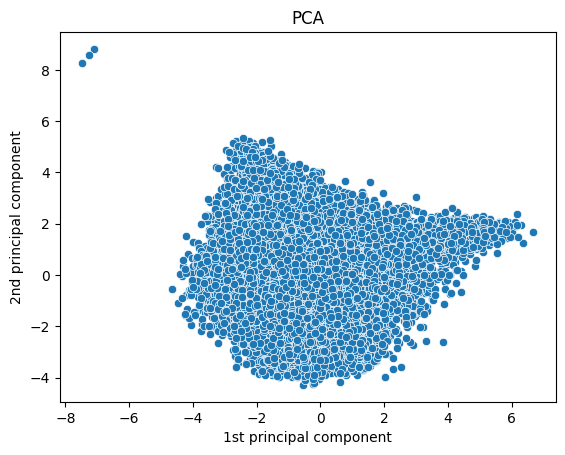

,popularity,danceability,energy,loudness,valence,speechiness,acousticness,instrumentalness,duration_ms,name_len
4452,-0.578123,-0.857117,1.138816,0.949644,-1.227952,-1.077275,-14.0,-0.057496,5.413087,1.041393
4510,-1.099942,-2.255668,1.105373,0.280891,-1.838314,-1.036212,-14.0,-0.088842,5.585100,0.602060
10785,-0.694083,-1.317324,1.368742,0.352225,-1.842461,-0.970616,-14.0,-0.041436,5.424568,0.903090


In [48]:
data = PCA(2).fit_transform(x)
sns.scatterplot(x=data[:, 0], y=data[:, 1])
plt.title("PCA")
plt.xlabel("1st principal component")
plt.ylabel("2nd principal component")
plt.show();
x.loc[data[:, 0] < -6]

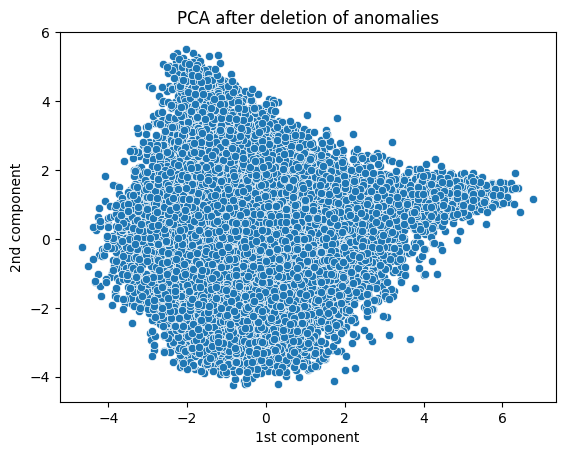

In [49]:
data = PCA(2).fit_transform(x.drop(index=[4452, 4510, 10785]))
sns.scatterplot(x=data[:, 0], y=data[:, 1])
plt.title("PCA after deletion of anomalies")
plt.xlabel("1st component")
plt.ylabel("2nd component")
plt.show();

# Read preprocessed data

In [3]:
df = pd.read_csv("data_files/preprocessed.csv")
df = df.fillna(df.median())
scaler = ColumnTransformer(
    [
        ("std_scaler", StandardScaler(), [
            "popularity", "danceability", "energy", "loudness",
            "valence"
        ]),
        ("log_scaler", FunctionTransformer(
            lambda x: np.log10(x + 1e-14), lambda x: np.power(10, x)
            ), [
                "speechiness", "acousticness", "instrumentalness",
                "duration_ms", "name_len"
        ])
    ],
    remainder="passthrough"
)
df.drop(index=[4452, 4510, 10785], inplace=True)
x = df.drop(columns="class")
x = pd.DataFrame(scaler.fit_transform(x), columns=[
    "popularity", "danceability", "energy", "loudness",
    "valence", "speechiness", "acousticness", "instrumentalness",
    "duration_ms", "name_len"
])
y = df.loc[:, "class"]

# Hierarchy clustering

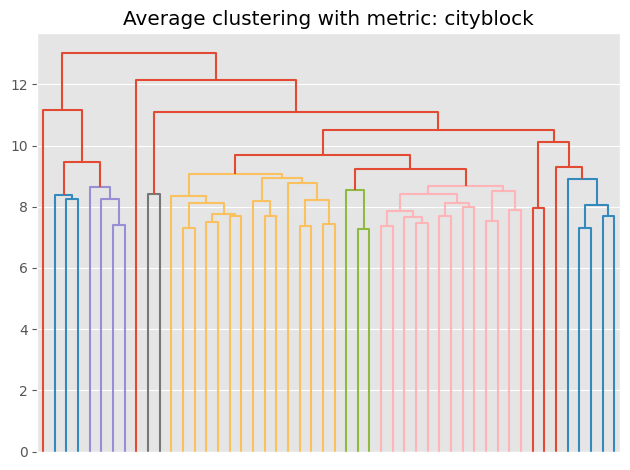

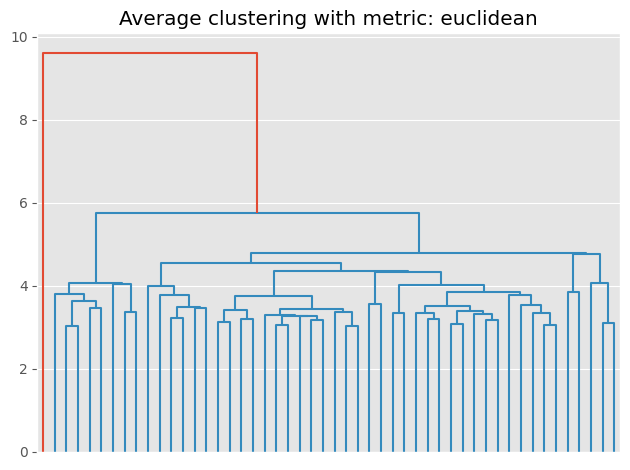

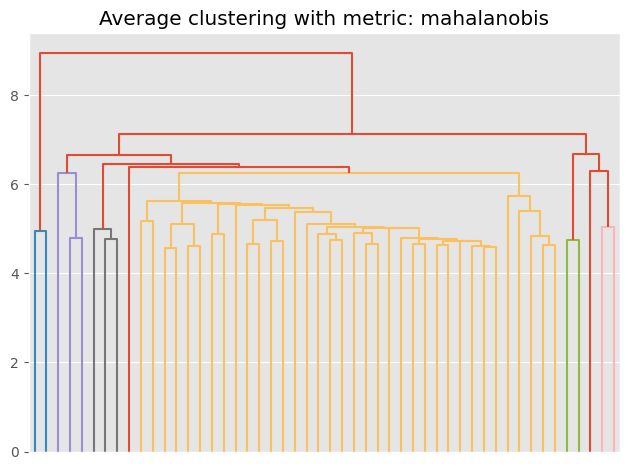

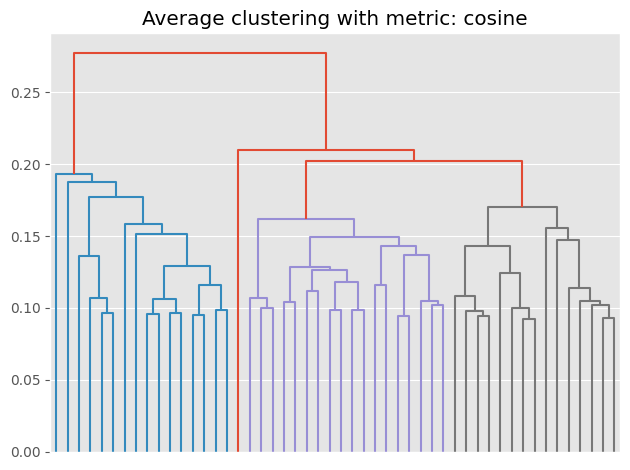

In [54]:
with plt.style.context("ggplot"):
    for metric in ["cityblock", "euclidean", "mahalanobis", "cosine"]:
        link = linkage(x, "average", metric)
        dendrogram(link, p=50, truncate_mode="lastp", no_labels=True)
        plt.title("Average clustering with metric: " + metric)
        plt.tight_layout()
        plt.show();

Select cosine metric with 0.17 distance threshold. More divergence of clusters is obtained by this metric.

Quadratic increasing of time consumption

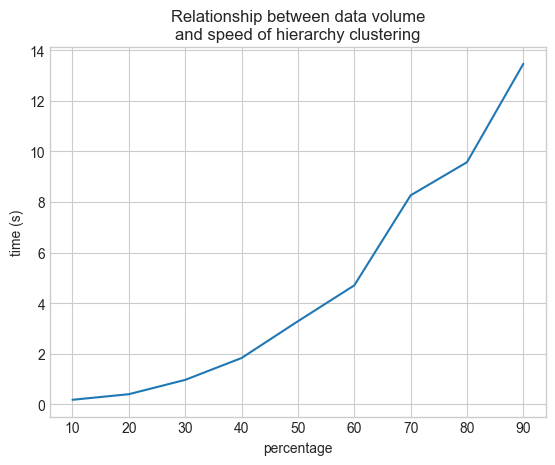

In [58]:
times = []
for perc in range(10, 91, 10):
    tm = 0
    for i in range(5):
        start = time()
        link = linkage(
            x.sample(frac=perc / 100, random_state=i),
            "average", "cityblock"
        )
        tm += time() - start
    times.append(tm / 5)
with plt.style.context("seaborn-v0_8-whitegrid"):
    sns.lineplot(x=list(range(10, 91, 10)), y=times)
    plt.title("Relationship between data volume\nand speed of hierarchy clustering")
    plt.xlabel("percentage")
    plt.ylabel("time (s)")
    plt.show();

Analysis of clustering

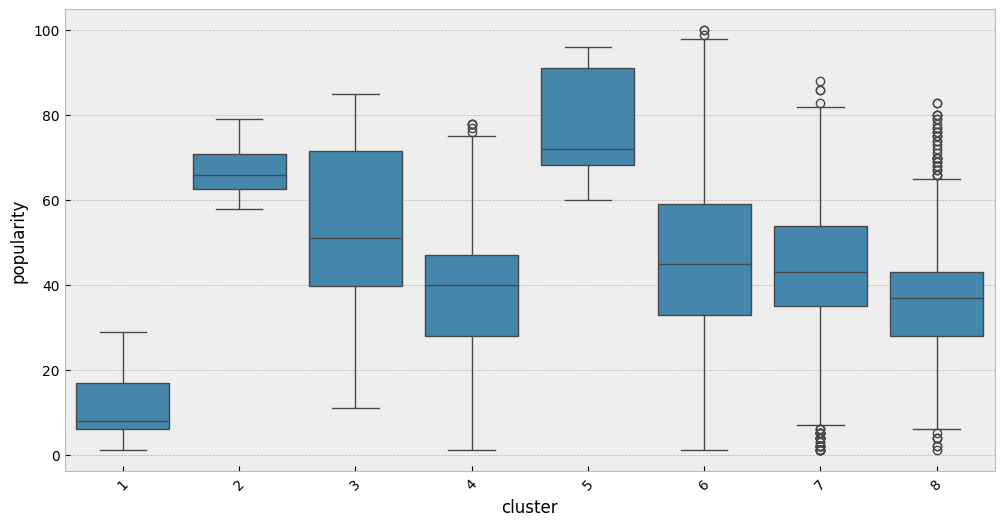

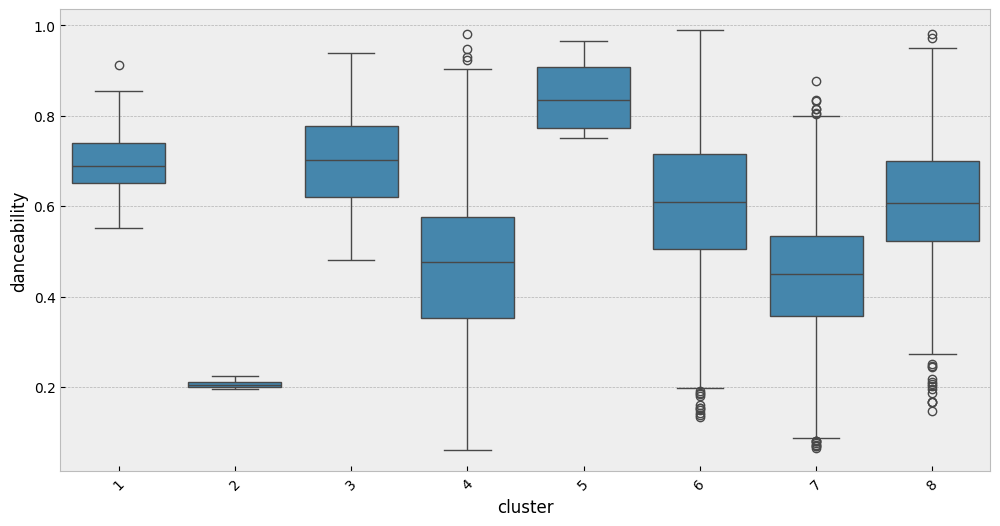

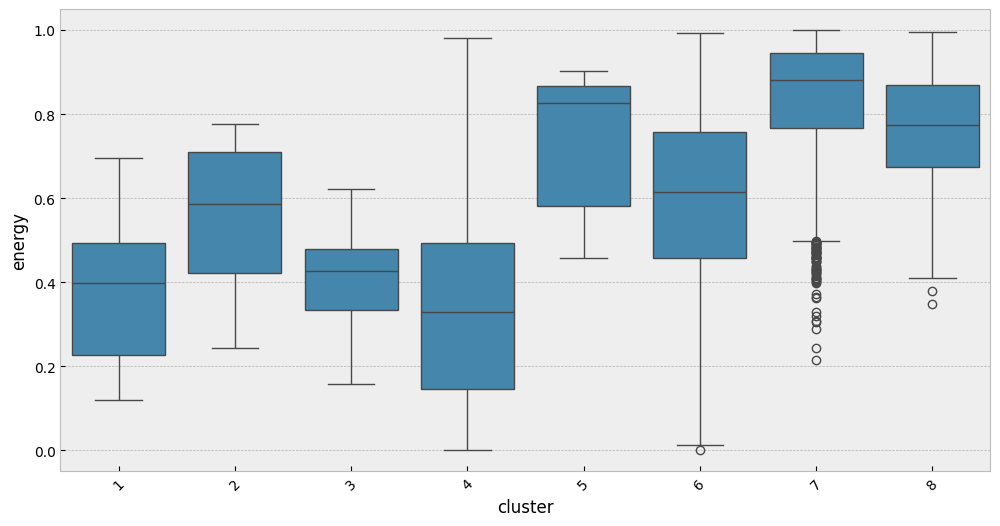

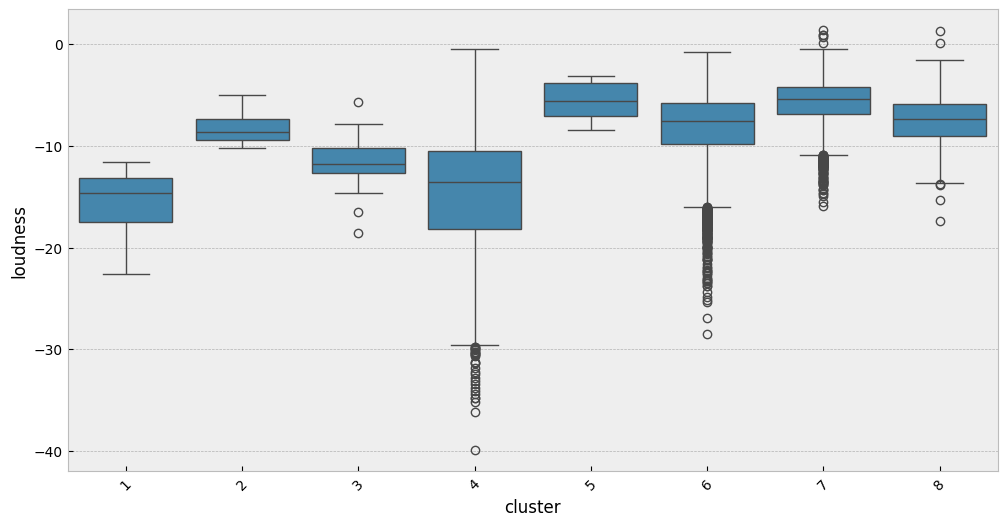

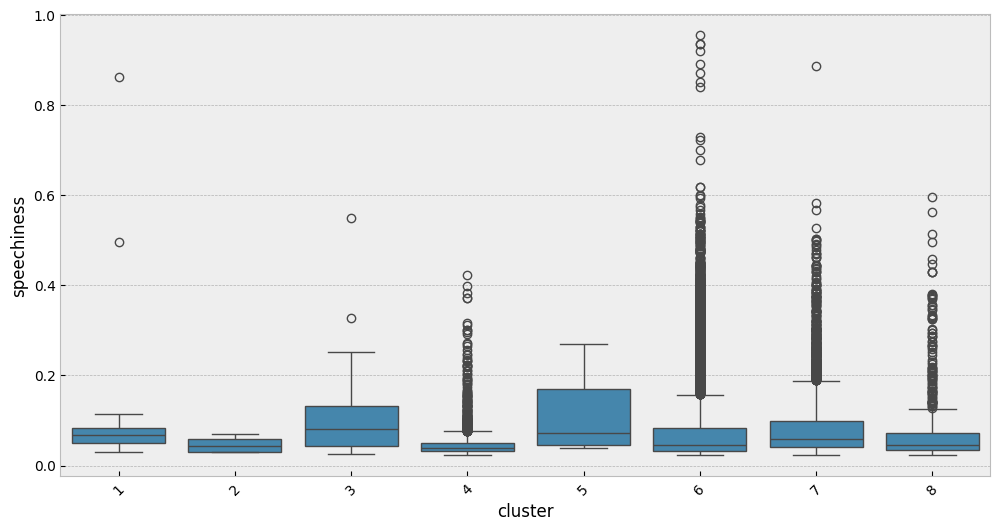

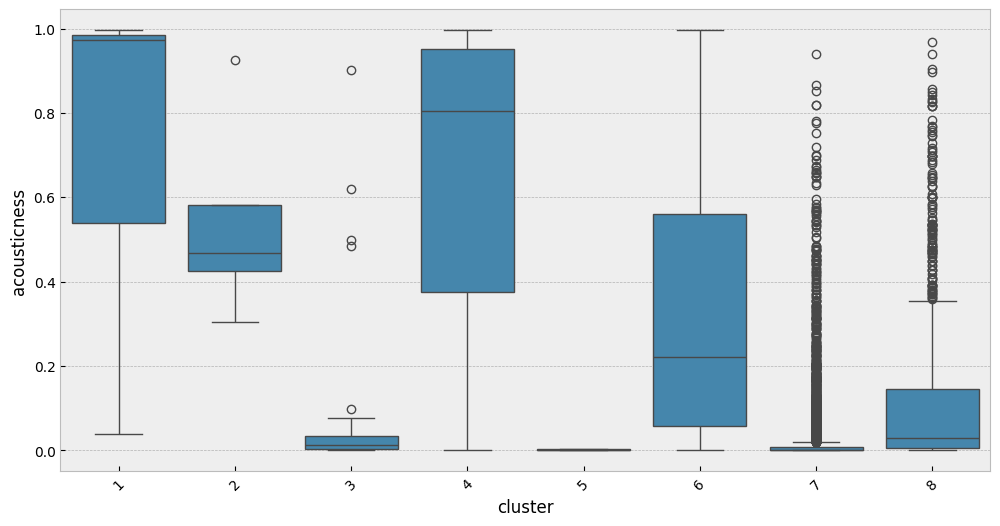

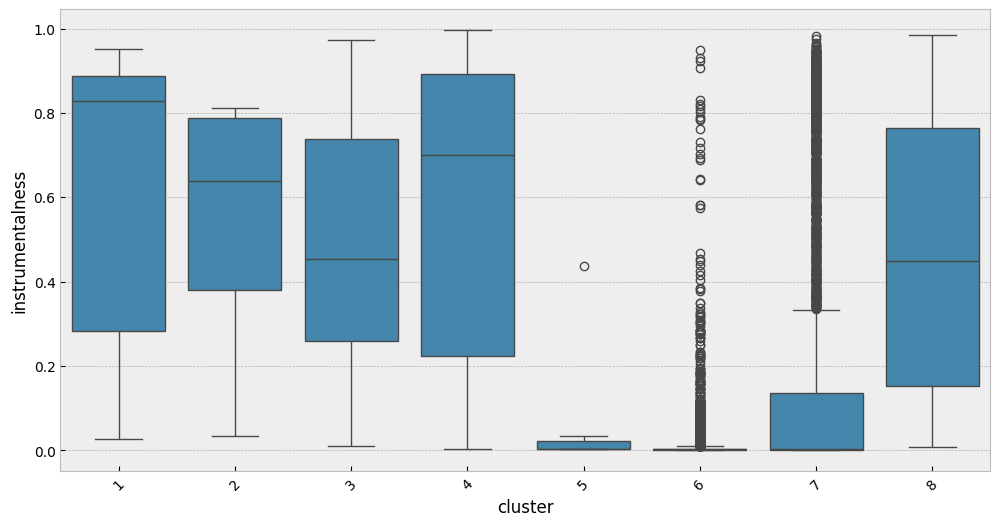

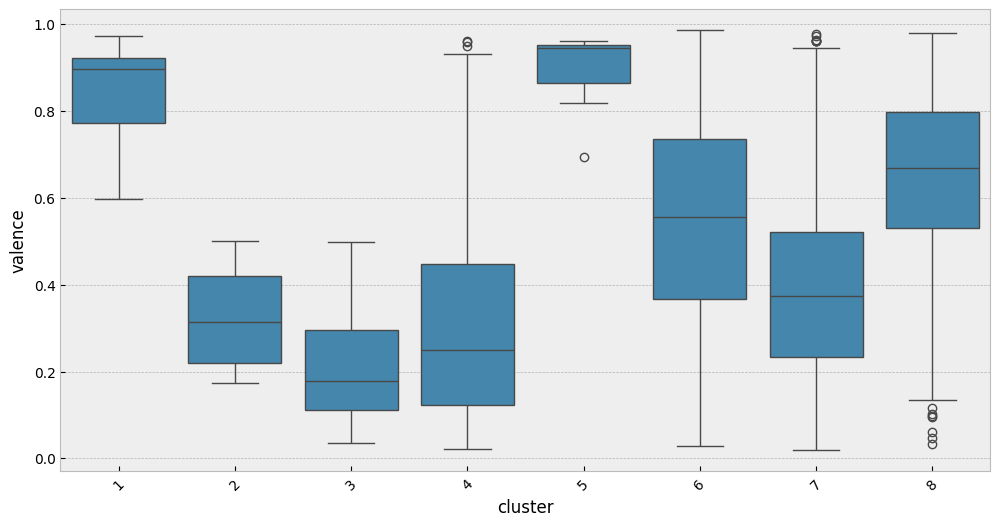

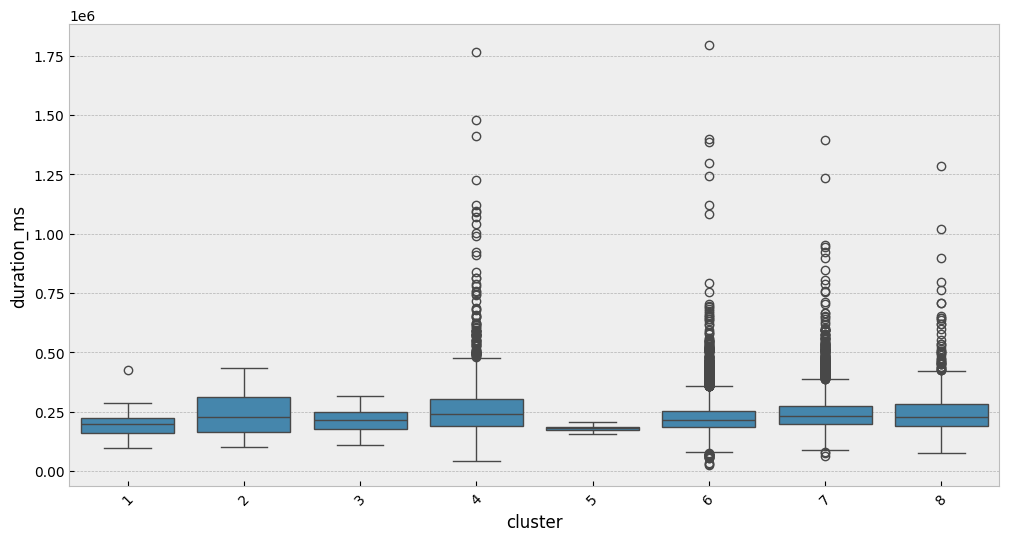

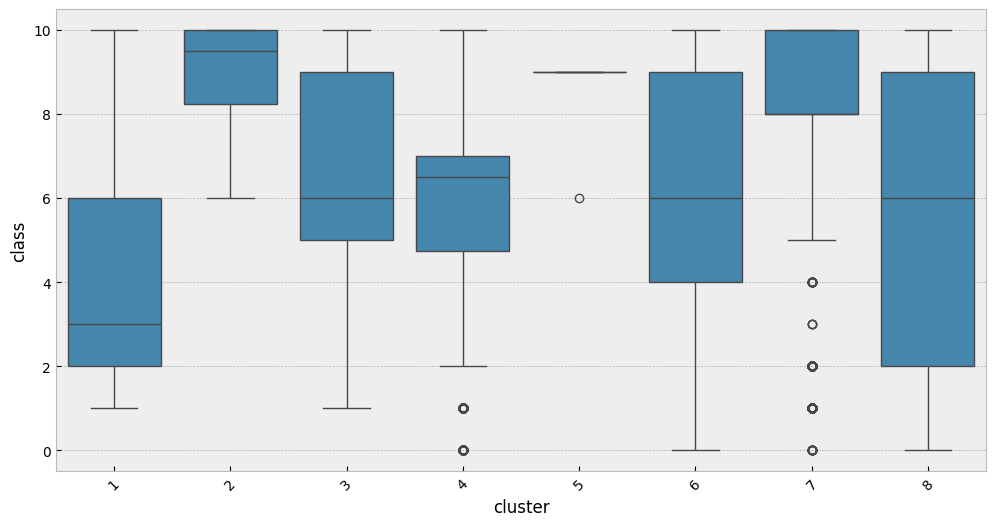

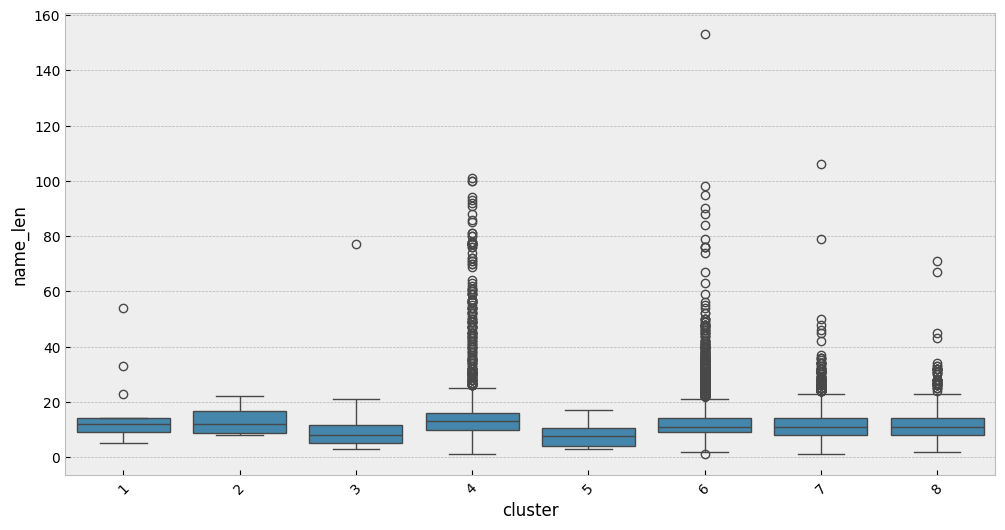

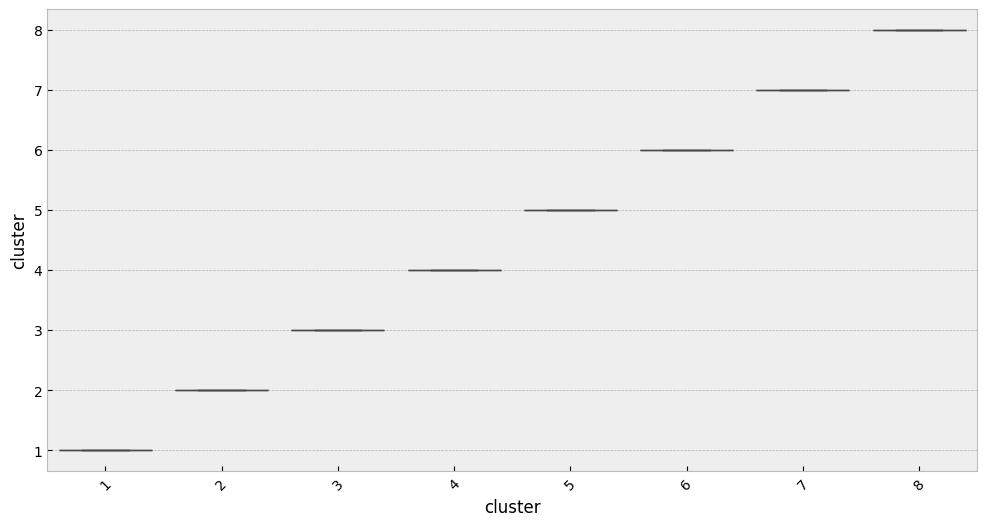

In [52]:
## different clusters have differente feature distributions
tmp = df.copy()
tmp["cluster"] = fcluster(linkage(x, "average", "cosine"), 0.17, "distance")
with plt.style.context("bmh"):
    for col in tmp.columns:
        plt.figure(figsize = (12, 6))
        ax = sns.boxplot(x=tmp["cluster"], y=tmp.loc[:, col])
        plt.setp(ax.artists, alpha=.5, linewidth=2, edgecolor="k")
        plt.xticks(rotation=45)
        plt.show();

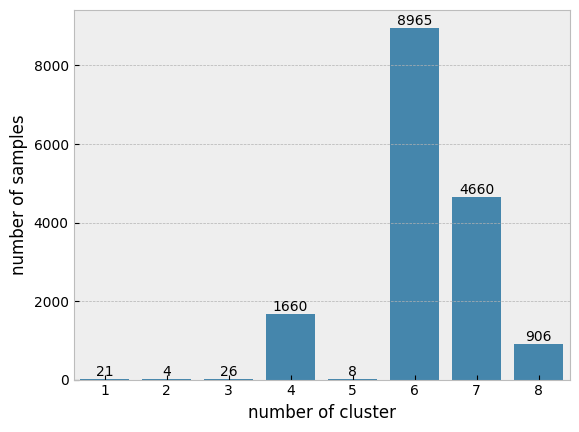

In [53]:
with plt.style.context("bmh"):
    ax = sns.barplot(data=Counter(tmp["cluster"]))
    ax.bar_label(ax.containers[0], fontsize=10)
    plt.xlabel("number of cluster")
    plt.ylabel("number of samples")
    plt.show();

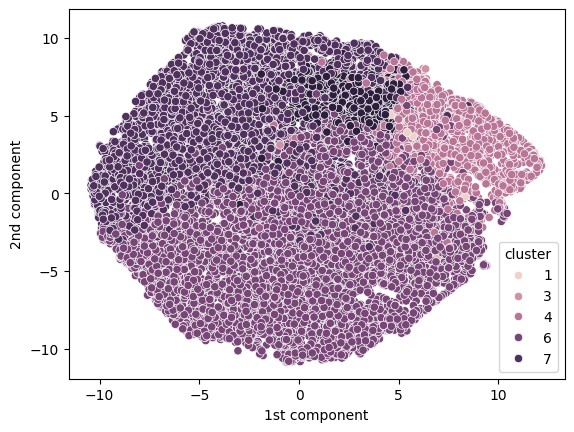

In [227]:
data = TSNE(2, max_iter=300).fit_transform(x)
sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=tmp["cluster"])
plt.xlabel("1st component")
plt.ylabel("2nd component")
plt.show();

In [228]:
print(f"Silhouette score: {round(silhouette_score(x, tmp["cluster"]), 4)}")
print(f"Calinski Harabasz score: {round(calinski_harabasz_score(x, tmp["cluster"]), 4)}")
print(f"Davies Bouldin score: {round(davies_bouldin_score(x, tmp["cluster"]), 4)}")

Silhouette score: 0.0609
Calinski Harabasz score: 1227.3402
Davies Bouldin score: 1.4856


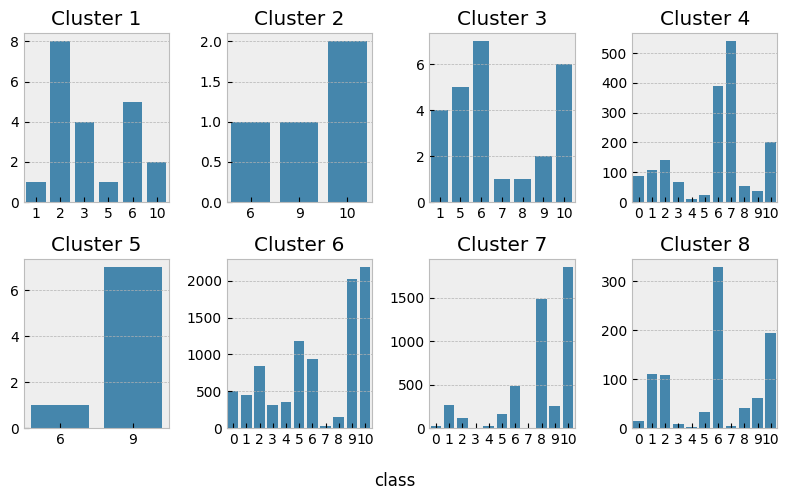

In [45]:
with plt.style.context("bmh"):
    fig, axs = plt.subplots(2, 4, figsize=(8, 5))
    fig.supxlabel("class")
    for i, cl in enumerate(np.unique(tmp["cluster"])):
        sns.barplot(
            Counter(tmp.loc[tmp.loc[:, "cluster"] == cl, "class"]),
            ax=axs[i // 4, i % 4]
        )
        axs[i // 4, i % 4].set_title(f"Cluster {cl}")
plt.tight_layout()
plt.show();

In [230]:
for cl in np.unique(tmp["cluster"]):
    print("cluster", cl, "classes", Counter(tmp.loc[tmp.loc[:, "cluster"] == cl, "class"]))

cluster 1 classes Counter({2: 8, 6: 5, 3: 4, 10: 2, 5: 1, 1: 1})
cluster 2 classes Counter({10: 2, 9: 1, 6: 1})
cluster 3 classes Counter({6: 7, 10: 6, 5: 5, 1: 4, 9: 2, 7: 1, 8: 1})
cluster 4 classes Counter({7: 539, 6: 390, 10: 201, 2: 141, 1: 109, 0: 88, 3: 68, 8: 54, 9: 36, 5: 25, 4: 9})
cluster 5 classes Counter({9: 7, 6: 1})
cluster 6 classes Counter({10: 2180, 9: 2029, 5: 1180, 6: 934, 2: 845, 0: 502, 1: 448, 4: 349, 3: 319, 8: 148, 7: 31})
cluster 7 classes Counter({10: 1849, 8: 1483, 6: 480, 1: 271, 9: 251, 5: 160, 2: 114, 4: 27, 0: 21, 3: 3, 7: 1})
cluster 8 classes Counter({6: 328, 10: 194, 1: 111, 2: 108, 9: 62, 8: 42, 5: 33, 0: 14, 3: 8, 7: 4, 4: 2})


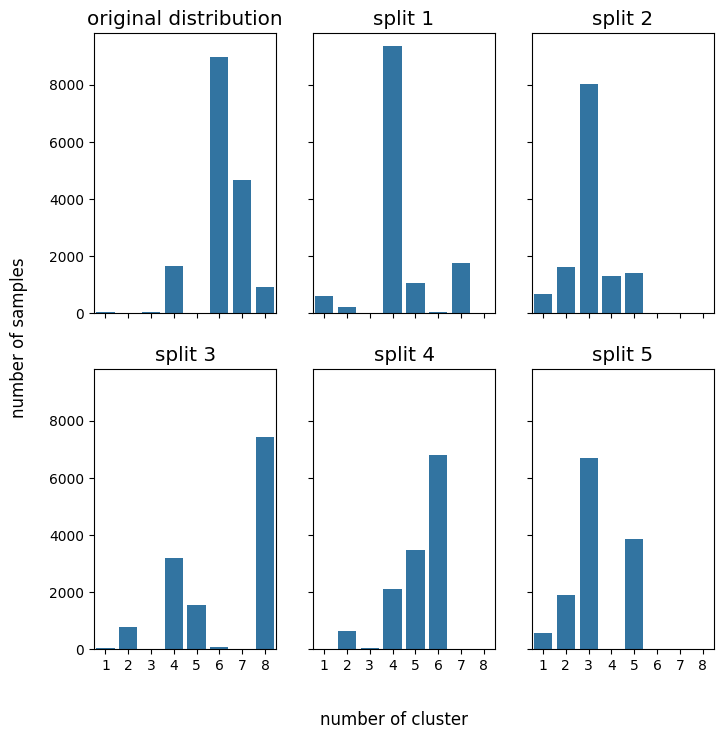

In [235]:
cl_distr = {}
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(8, 8))
with plt.style.context("bmh"):
    sns.barplot(data=Counter(tmp["cluster"]), ax=axs[0, 0])
    axs[0, 0].set_title("original distribution")
for i, (train, _) in enumerate(StratifiedKFold(5).split(x, y), 1):
    cl = fcluster(linkage(x.iloc[train], "average", "cosine"), 0.17, "distance")
    with plt.style.context("bmh"):
        sns.barplot(data=Counter(cl), ax=axs[i // 3, i % 3])
        axs[i // 3, i % 3].set_title(f"split {i}")
fig.supxlabel("number of cluster")
fig.supylabel("number of samples")
plt.show();

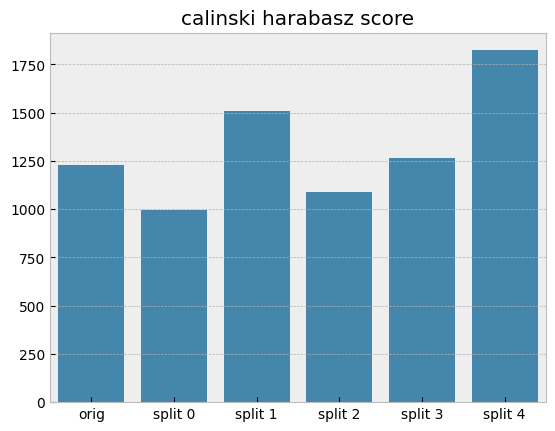

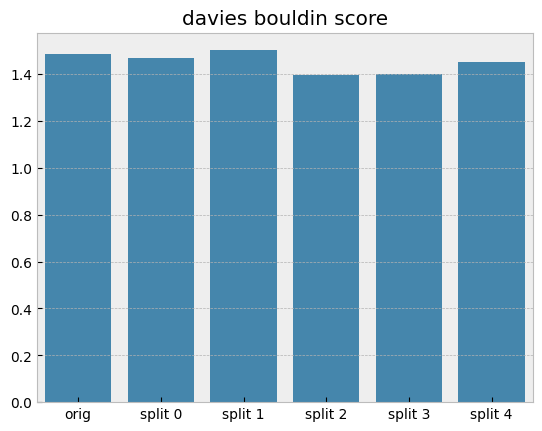

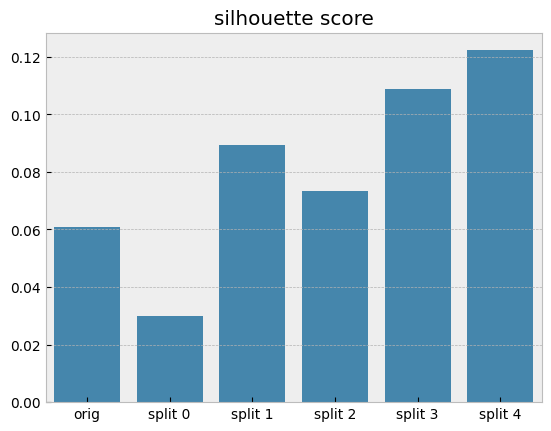

In [ ]:
n_splits = 5
clus_distr = {
    "calinski harabasz": [calinski_harabasz_score(x, tmp["cluster"])],
    "davies bouldin": [davies_bouldin_score(x, tmp["cluster"])],
    "silhouette": [silhouette_score(x, tmp["cluster"])]
}
for i, (train, _) in enumerate(StratifiedKFold(n_splits).split(x, y), 1):
    cl = fcluster(linkage(x.iloc[train], "average", "cosine"), 0.17, "distance")
    clus_distr["calinski harabasz"].append(calinski_harabasz_score(x.iloc[train], cl))
    clus_distr["davies bouldin"].append(davies_bouldin_score(x.iloc[train], cl))
    clus_distr["silhouette"].append(silhouette_score(x.iloc[train], cl))

for key in clus_distr:
    with plt.style.context("bmh"):
        sns.barplot(
            x=["orig"] + [f"split {i}" for i in range(n_splits)],
            y=clus_distr[key]
        ).bar_label()
        plt.title(key + " score")
        plt.show();

# KMeans clustering

appropriate number of clusters is 4

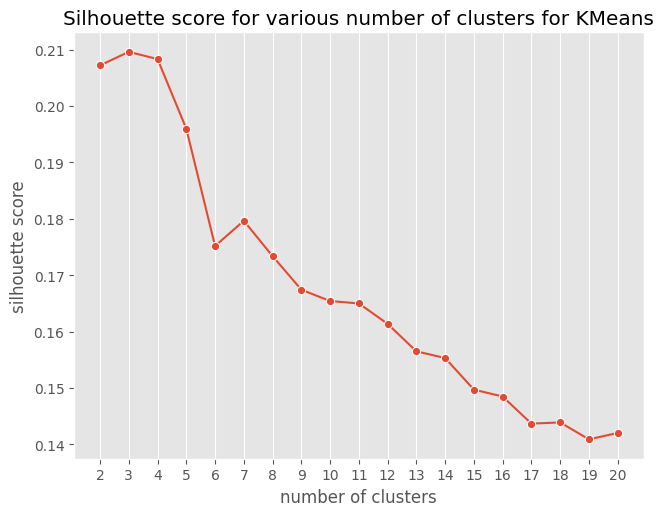

In [61]:
## search the most appropriate number of clusters
silh_scores = []
for n in range(2, 21):
    kmeans = KMeans(n, random_state=17)
    kmeans.fit(x)
    silh_scores.append(silhouette_score(x, kmeans.labels_, metric="euclidean"))
with plt.style.context("ggplot"):
    sns.lineplot(x=range(2, 21), y=silh_scores, marker="o")
    plt.tight_layout()
    plt.xlabel("number of clusters")
    plt.ylabel("silhouette score")
    plt.title("Silhouette score for various number of clusters for KMeans")
    plt.grid(axis="y")
    plt.xticks(range(2, 21), list(map(str, range(2, 21))))
    plt.show();

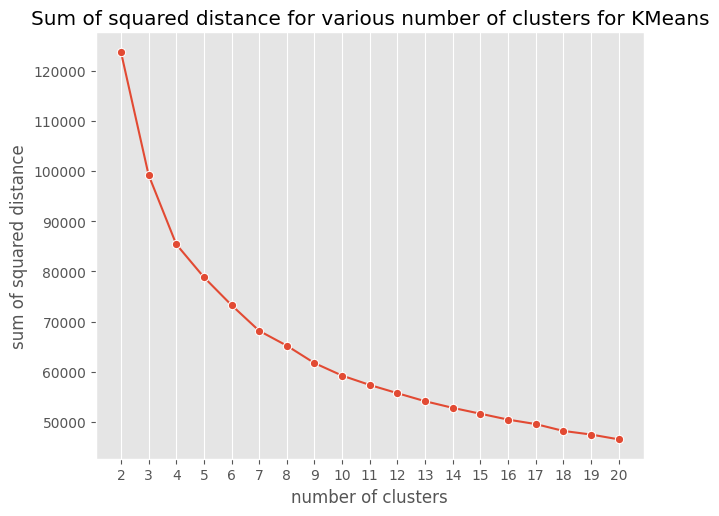

In [66]:
inertia = []
for n in range(2, 21):
    kmeans = KMeans(n, random_state=17)
    kmeans.fit(x)
    inertia.append(kmeans.inertia_)
with plt.style.context("ggplot"):
    sns.lineplot(x=range(2, 21), y=inertia, marker="o")
    plt.tight_layout()
    plt.xlabel("number of clusters")
    plt.ylabel("sum of squared distance")
    plt.title("Sum of squared distance for various number of clusters for KMeans")
    plt.grid(axis="y")
    plt.xticks(range(2, 21), list(map(str, range(2, 21))))
    plt.show();

In [74]:
## elbow method to define number of clusters
mn = 1e7
id = 0
for i in range(1, len(inertia) - 1):
    if abs(inertia[i] - inertia[i + 1]) / abs(inertia[i - 1] - inertia[i]) < mn:
        mn = abs(inertia[i] - inertia[i + 1]) / abs(inertia[i - 1] - inertia[i])
        id = i
print(list(range(2, 20))[id])

4


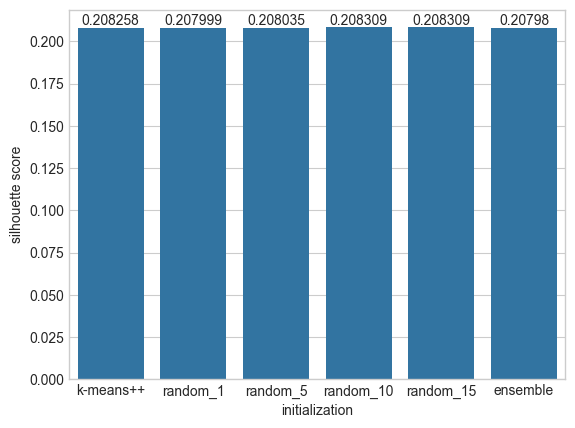

{'k-means++': Counter({np.int32(2): 6035, np.int32(3): 3668, np.int32(0): 3568, np.int32(1): 2979}), 'random_1': Counter({np.int32(3): 5993, np.int32(1): 3666, np.int32(0): 3564, np.int32(2): 3027}), 'random_5': Counter({np.int32(0): 6000, np.int32(1): 3667, np.int32(2): 3567, np.int32(3): 3016}), 'random_10': Counter({np.int32(1): 6040, np.int32(0): 3668, np.int32(3): 3568, np.int32(2): 2974}), 'random_15': Counter({np.int32(1): 6040, np.int32(0): 3668, np.int32(3): 3568, np.int32(2): 2974})}


In [12]:
silh_scores = {}
distr = {}
for init in ["k-means++", "random_1", "random_5", "random_10", "random_15"]:
    if "random" in init:
        kmeans = KMeans(
            4, init=init.split("_")[0], n_init=int(init.split("_")[1]),
            random_state=17
        )
        silh_scores[init] = silhouette_score(
            x, kmeans.fit(x).labels_, metric="euclidean"
        )
    else:
        kmeans = KMeans(
            4, init=init, random_state=17
        )
        silh_scores[init] = silhouette_score(
            x, kmeans.fit(x).labels_, metric="euclidean"
        )
    distr[init] = Counter(kmeans.labels_)
silh_scores["ensemble"] = silhouette_score(x, EnsembleKMeans(4).fit(x).labels_)
with plt.style.context("seaborn-v0_8-whitegrid"):
    ax = sns.barplot(silh_scores)
    ax.bar_label(ax.containers[0], fontsize=10)
    plt.xlabel("initialization")
    plt.ylabel("silhouette score")
    plt.show();
print(distr)

Analysis of clustering

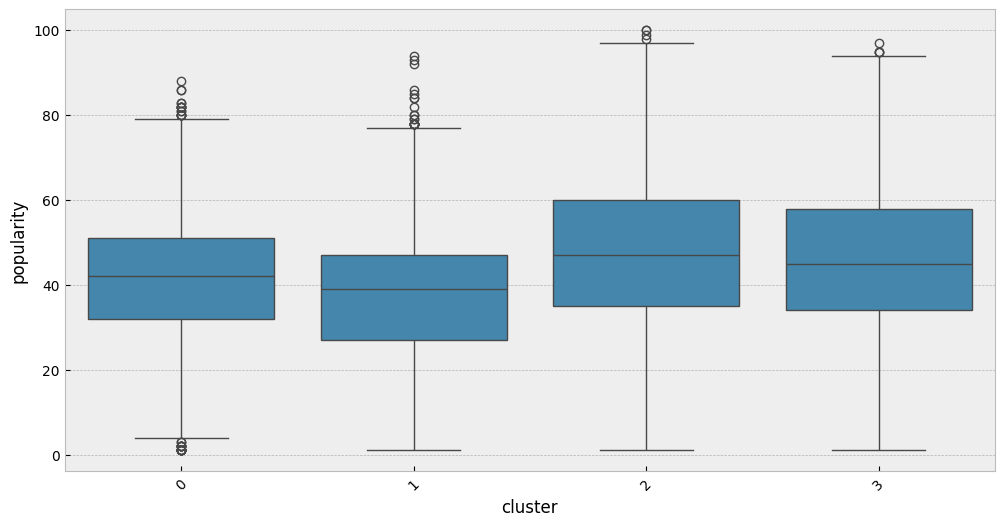

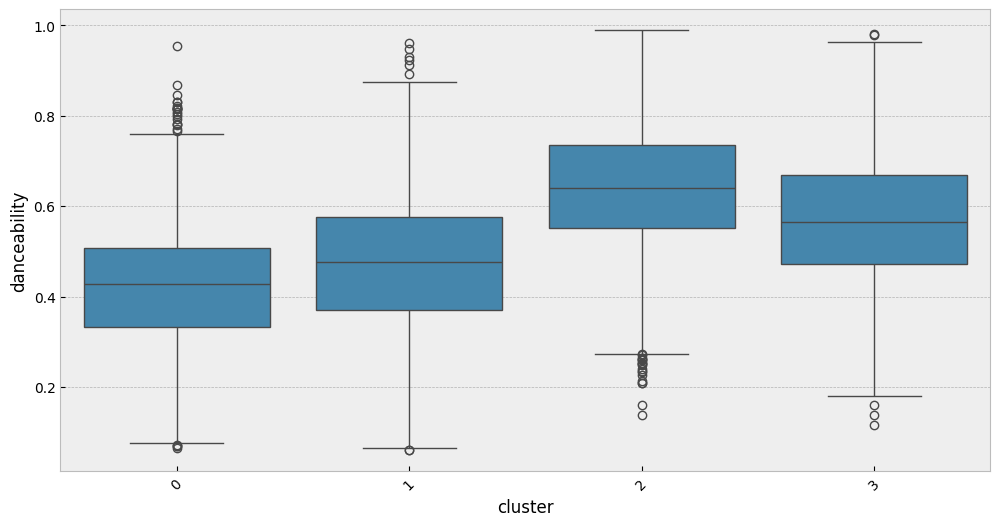

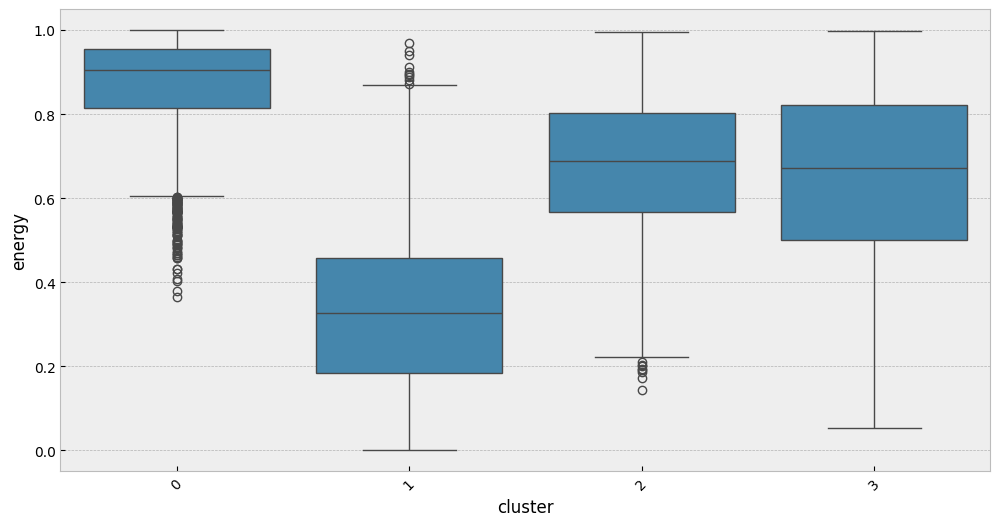

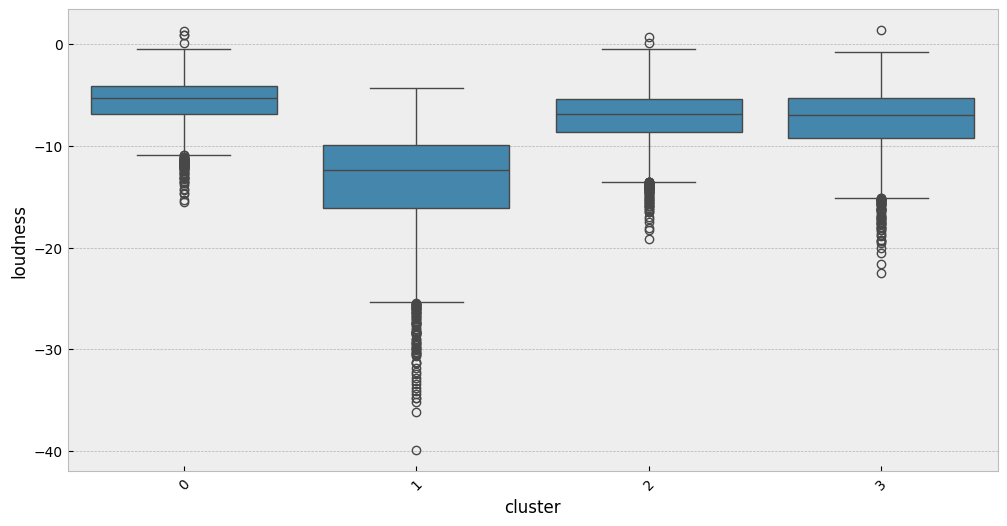

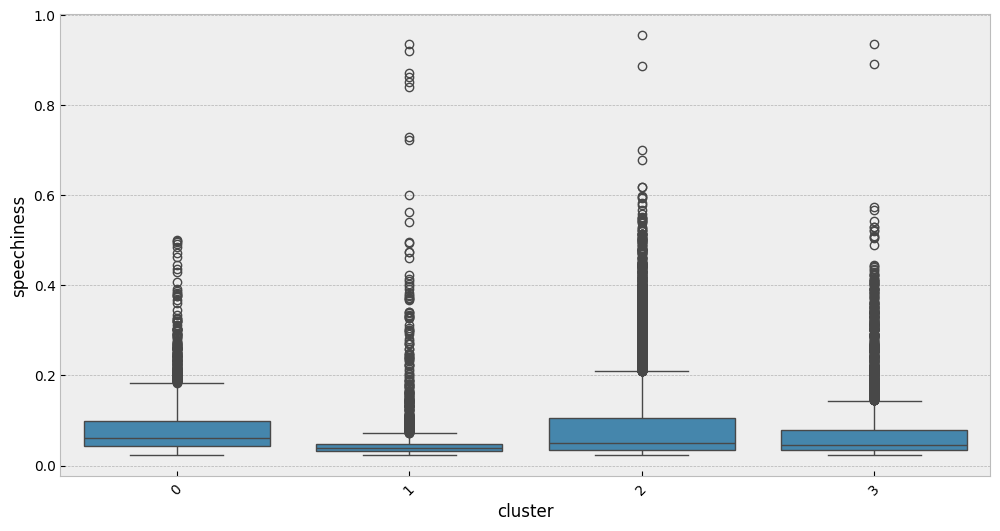

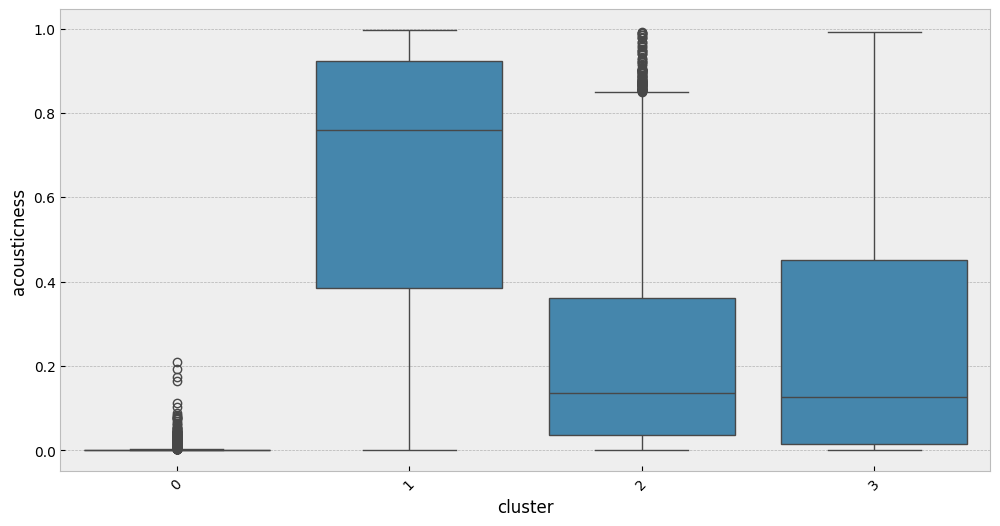

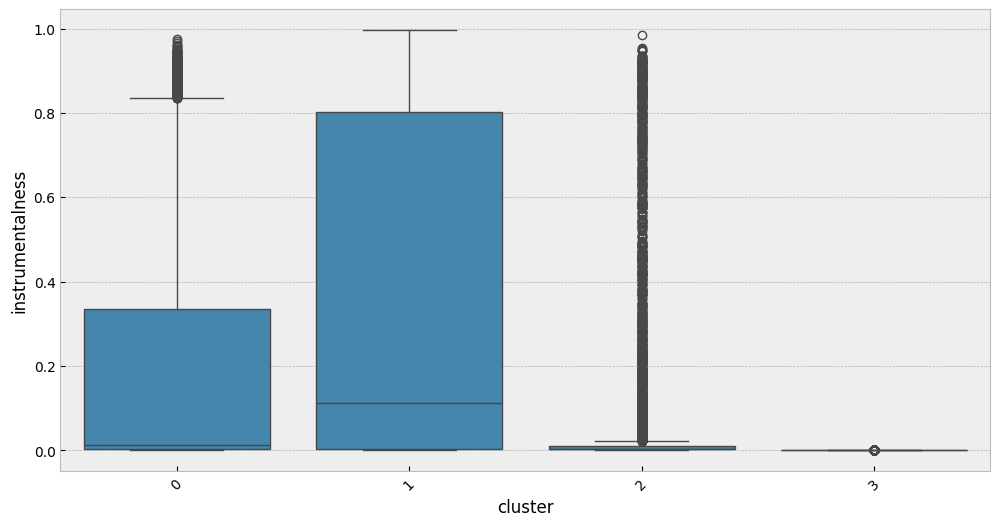

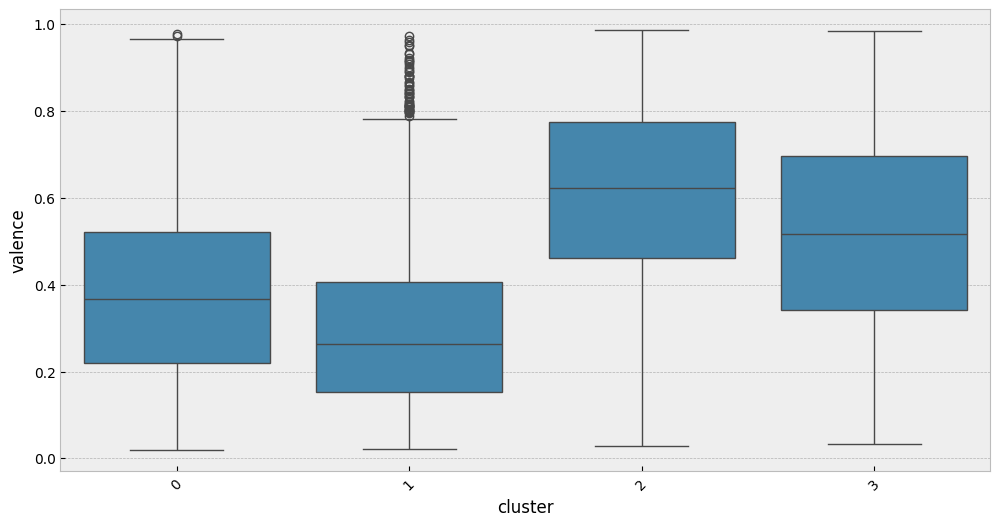

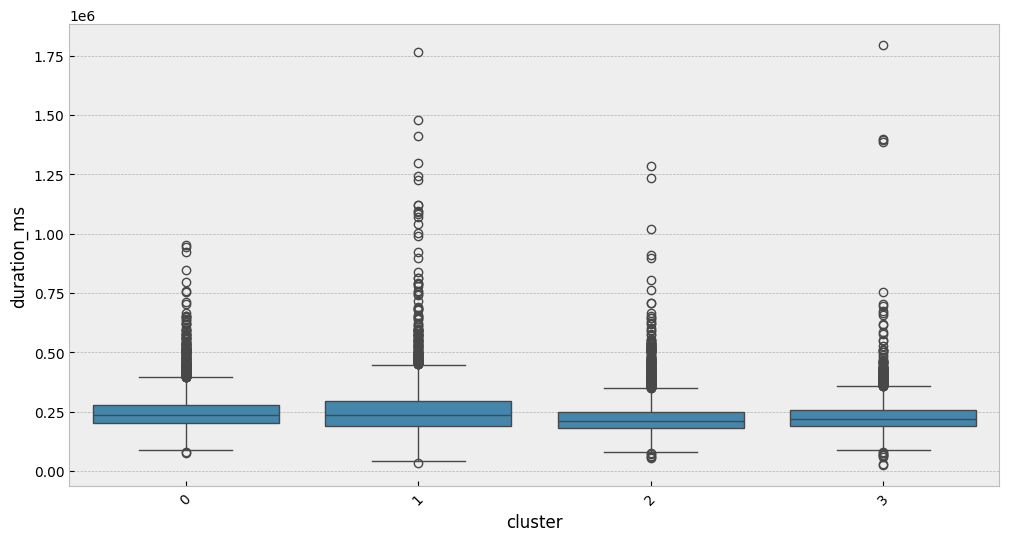

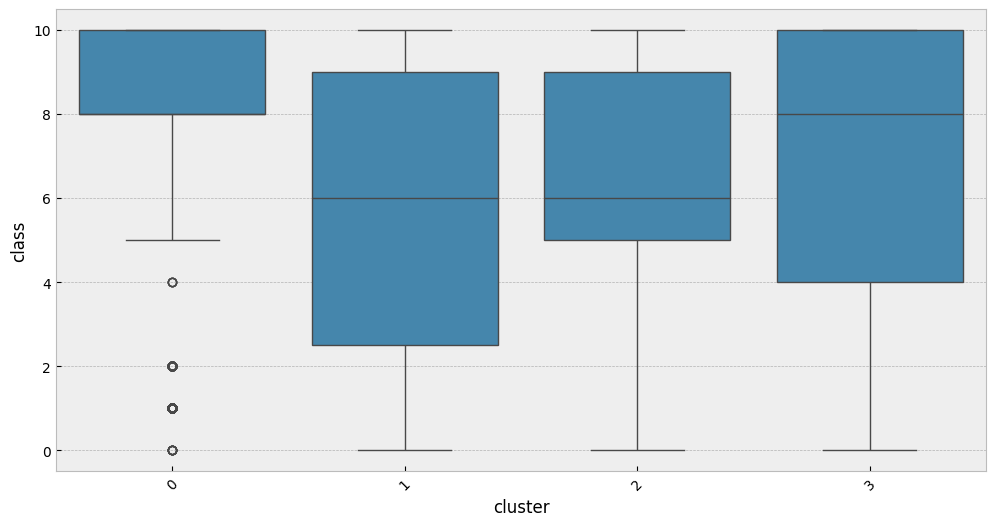

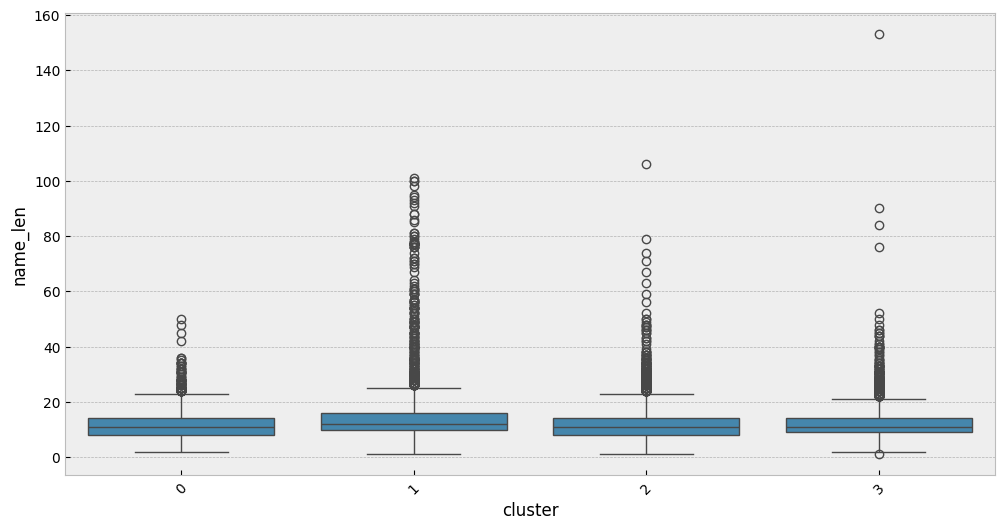

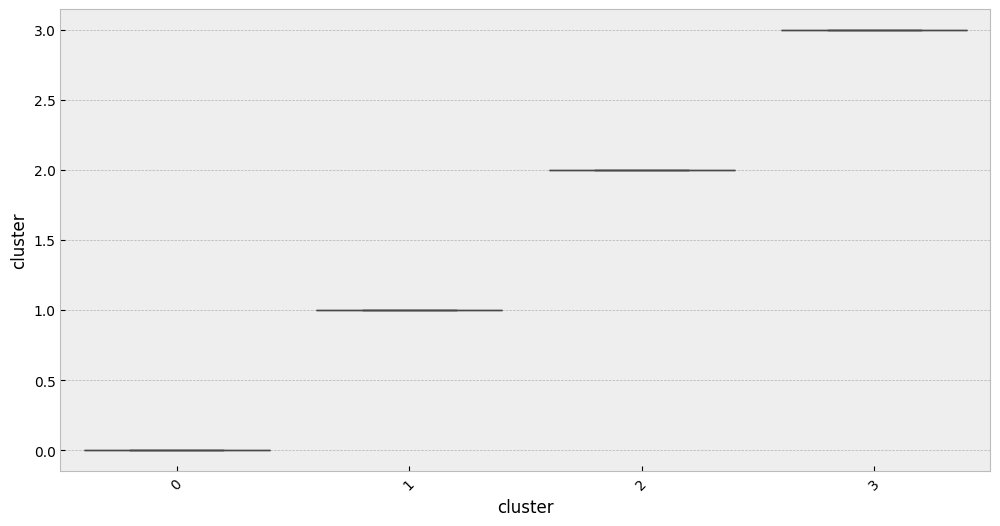

In [24]:
## different clusters haven't mostly differente feature distributions
tmp = df.copy()
tmp["cluster"] = KMeans(4, init="k-means++", random_state=17).fit(x).labels_
with plt.style.context("bmh"):
    for col in tmp.columns:
        plt.figure(figsize = (12, 6))
        ax = sns.boxplot(x=tmp["cluster"], y=tmp.loc[:, col])
        plt.setp(ax.artists, alpha=.5, linewidth=2, edgecolor="k")
        plt.xticks(rotation=45)
        plt.show();

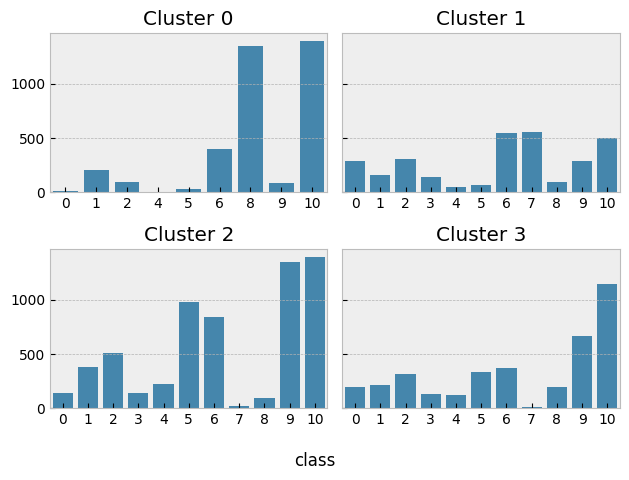

In [35]:
with plt.style.context("bmh"):
    fig, axs = plt.subplots(2, 2, sharey=True)
    fig.supxlabel("class")
    for i, cl in enumerate(np.unique(tmp["cluster"])):
        sns.barplot(
            Counter(tmp.loc[tmp.loc[:, "cluster"] == cl, "class"]),
            ax=axs[i // 2, i % 2]
        )
        axs[i // 2, i % 2].set_title(f"Cluster {cl}")
plt.tight_layout()
plt.show();

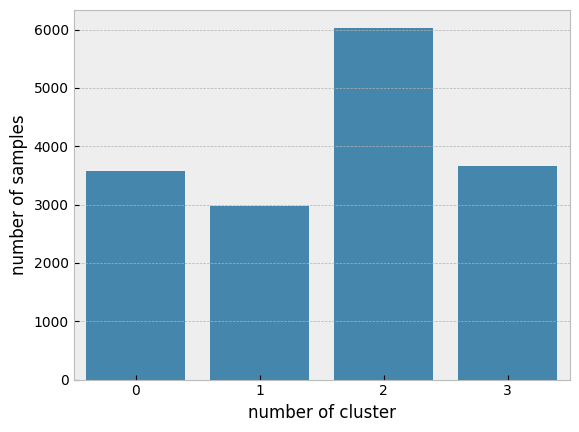

In [16]:
with plt.style.context("bmh"):
    sns.barplot(data=Counter(tmp["cluster"]))
    plt.xlabel("number of cluster")
    plt.ylabel("number of samples")
    plt.show();

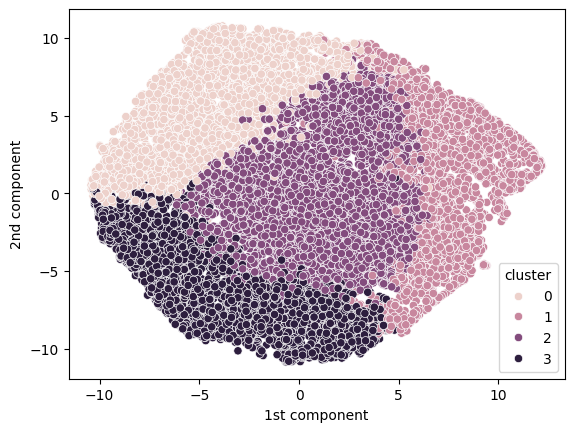

In [17]:
data = TSNE(2, max_iter=300, random_state=17).fit_transform(x)
sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=tmp["cluster"])
plt.xlabel("1st component")
plt.ylabel("2nd component")
plt.show();

In [18]:
print(f"Silhouette score: {round(silhouette_score(x, tmp["cluster"]), 4)}")
print(f"Calinski Harabasz score: {round(calinski_harabasz_score(x, tmp["cluster"]), 4)}")
print(f"Davies Bouldin score: {round(davies_bouldin_score(x, tmp["cluster"]), 4)}")

Silhouette score: 0.2083
Calinski Harabasz score: 4511.9738
Davies Bouldin score: 1.519


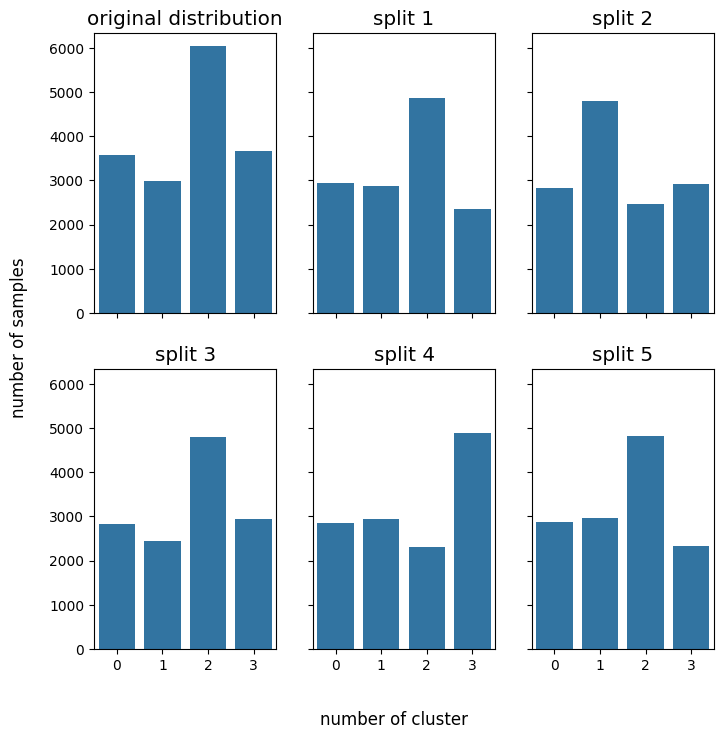

In [19]:
cl_distr = {}
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(8, 8))
with plt.style.context("bmh"):
    sns.barplot(data=Counter(tmp["cluster"]), ax=axs[0, 0])
    axs[0, 0].set_title("original distribution")
for i, (train, _) in enumerate(StratifiedKFold(5).split(x, y), 1):
    cl = KMeans(4, init="k-means++", random_state=17).fit(x.iloc[train]).labels_
    with plt.style.context("bmh"):
        sns.barplot(data=Counter(cl), ax=axs[i // 3, i % 3])
        axs[i // 3, i % 3].set_title(f"split {i}")
fig.supxlabel("number of cluster")
fig.supylabel("number of samples")
plt.show();

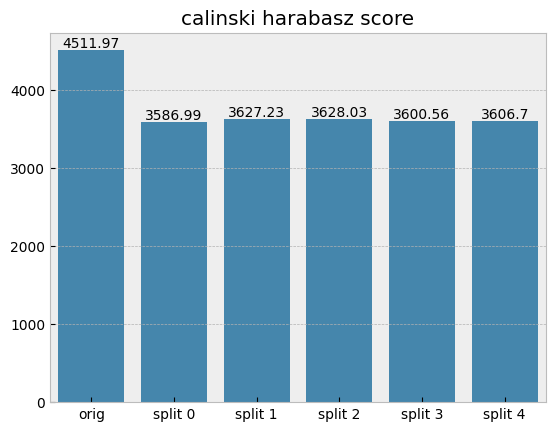

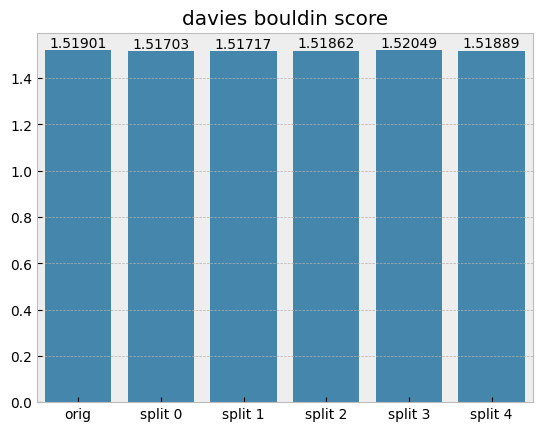

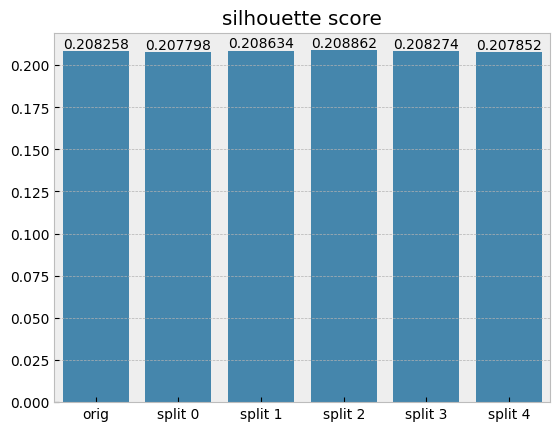

In [ ]:
n_splits = 5
clus_distr = {
    "calinski harabasz": [calinski_harabasz_score(x, tmp["cluster"])],
    "davies bouldin": [davies_bouldin_score(x, tmp["cluster"])],
    "silhouette": [silhouette_score(x, tmp["cluster"])]
}
for i, (train, _) in enumerate(StratifiedKFold(n_splits).split(x, y), 1):
    cl = KMeans(4, init="k-means++", random_state=17).fit(x.iloc[train]).labels_
    clus_distr["calinski harabasz"].append(calinski_harabasz_score(x.iloc[train], cl))
    clus_distr["davies bouldin"].append(davies_bouldin_score(x.iloc[train], cl))
    clus_distr["silhouette"].append(silhouette_score(x.iloc[train], cl))

for key in clus_distr:
    with plt.style.context("bmh"):
        ax = sns.barplot(
            x=["orig"] + [f"split {i}" for i in range(n_splits)],
            y=clus_distr[key]
        )
        ax.bar_label(ax.containers[0], fontsize=10)
        plt.title(key + " score")
        plt.show();

# DBSCAN clustering

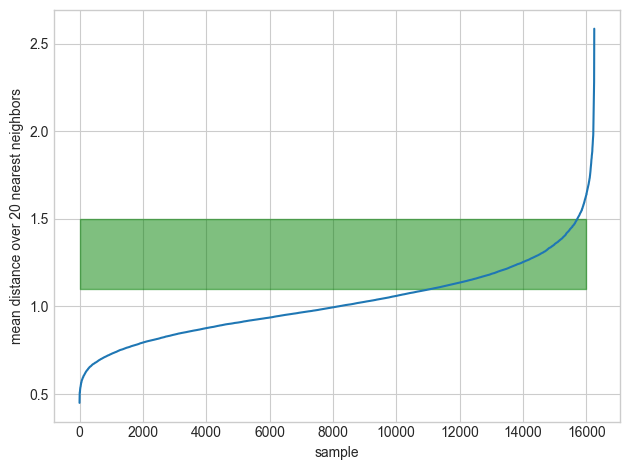

In [179]:
k = 2 * x.shape[1]
nn = NearestNeighbors(n_neighbors=k, n_jobs=-1).fit(x)
distance, _ = nn.kneighbors()
mean_dist = np.sort(np.mean(distance, axis=1))
with plt.style.context("seaborn-v0_8-whitegrid"):
    sns.lineplot(mean_dist)
    plt.ylabel(f"mean distance over {k} nearest neighbors")
    plt.xlabel("sample")
    plt.fill_between([0, 16000], [1.1, 1.1], [1.5, 1.5], alpha=0.5, color="g")
    plt.tight_layout()
    plt.show();

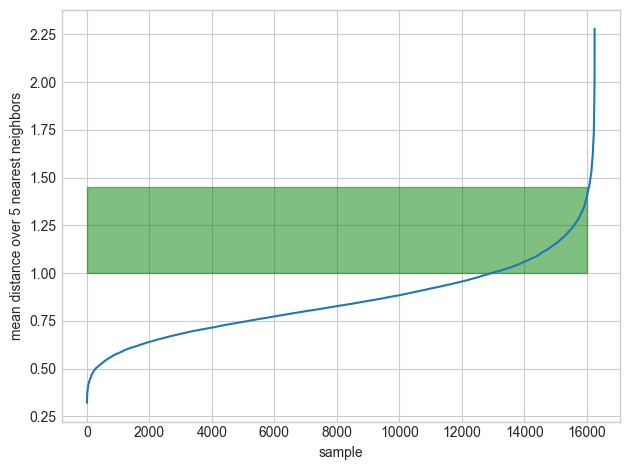

In [215]:
k = 5
nn = NearestNeighbors(n_neighbors=k, n_jobs=-1).fit(x)
distance, _ = nn.kneighbors()
mean_dist = np.sort(np.mean(distance, axis=1))
with plt.style.context("seaborn-v0_8-whitegrid"):
    sns.lineplot(mean_dist)
    plt.ylabel(f"mean distance over {k} nearest neighbors")
    plt.xlabel("sample")
    plt.fill_between([0, 16000], [1., 1.], [1.45, 1.45], alpha=0.5, color="g")
    plt.tight_layout()
    plt.show();

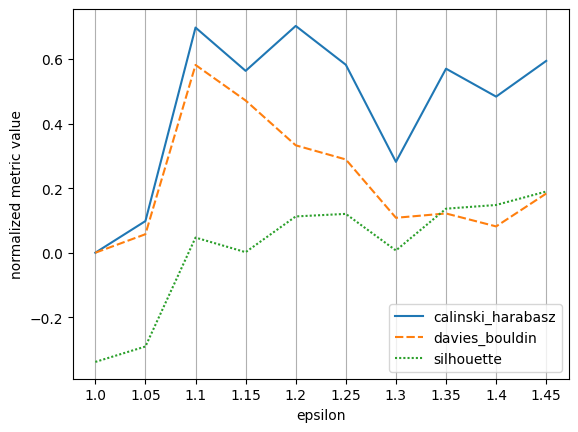

In [ ]:
scores = {"calinski_harabasz": [], "davies_bouldin": [], "silhouette": []}
for eps in np.linspace(1., 1.45, 10):
    labs = DBSCAN(eps, min_samples=5, n_jobs=-1).fit_predict(x)
    scores["calinski_harabasz"].append(calinski_harabasz_score(x, labs))
    scores["davies_bouldin"].append(davies_bouldin_score(x, labs))
    scores["silhouette"].append(silhouette_score(x, labs))
sns.lineplot({key: 
              (np.array(val) - min(val)) / max(val)
              if min(val) > 0 else val
              for key, val in scores.items()})
plt.xticks(range(10), [str(round(el, 3)) for el in np.linspace(1., 1.45, 10)])
plt.grid(axis="x")
plt.xlabel("epsilon")
plt.ylabel("normalized metric value")
plt.show()

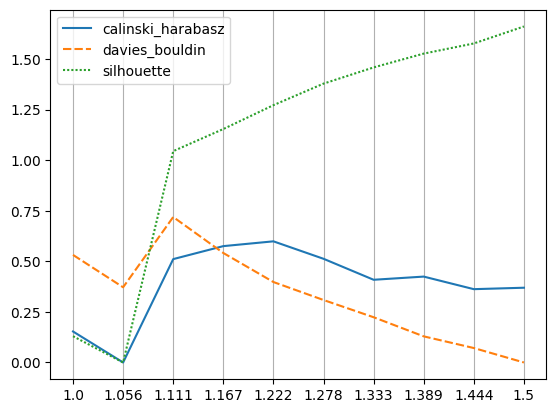

In [ ]:
scores = {"calinski_harabasz": [], "davies_bouldin": [], "silhouette": []}
for eps in np.linspace(1., 1.5, 10):
    labs = DBSCAN(eps, min_samples=2 * x.shape[1], n_jobs=-1).fit_predict(x)
    scores["calinski_harabasz"].append(calinski_harabasz_score(x, labs))
    scores["davies_bouldin"].append(davies_bouldin_score(x, labs))
    scores["silhouette"].append(silhouette_score(x, labs))
sns.lineplot({key: (np.array(val) - min(val)) / max(val) for key, val in scores.items()})
plt.xticks(range(10), [str(round(el, 3)) for el in np.linspace(1., 1.5, 10)])
plt.grid(axis="x")
plt.show()

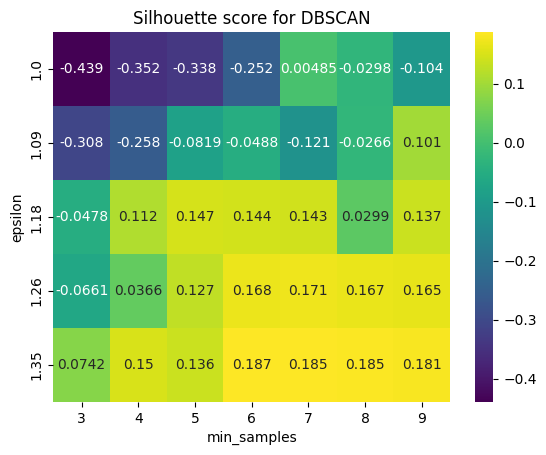

In [ ]:
surface = np.ndarray((7, 7))
for i, epsilon in enumerate(np.linspace(1., 1.45, 7)):
    for j, min_samples in enumerate(range(3, 10)):
        surface[i, j] = silhouette_score(
            x, DBSCAN(epsilon, min_samples=min_samples, n_jobs=-1).fit_predict(x),
            metric="euclidean"
        )
        print("end ", i, j)
sns.heatmap(surface, cmap="viridis", annot=True, fmt=".3g")
plt.xlabel("min samples")
plt.xticks([el + 0.5 for el in range(7)], list(map(str, range(3, 10))))
plt.yticks([el + 0.5 for el in range(5)], [str(round(num, 2)) for num in np.linspace(1., 1.35, 5)])
plt.ylabel("epsilon")
plt.title("Silhouette score for DBSCAN")
plt.show();

end  0 0
end  0 1
end  0 2
end  0 3
end  0 4
end  0 5
end  0 6
end  1 0
end  1 1
end  1 2
end  1 3
end  1 4
end  1 5
end  1 6
end  2 0
end  2 1
end  2 2
end  2 3
end  2 4
end  2 5
end  2 6
end  3 0
end  3 1
end  3 2
end  3 3
end  3 4
end  3 5
end  3 6
end  4 0
end  4 1
end  4 2
end  4 3
end  4 4
end  4 5
end  4 6
end  5 0
end  5 1
end  5 2
end  5 3
end  5 4
end  5 5
end  5 6
end  6 0
end  6 1
end  6 2
end  6 3
end  6 4
end  6 5
end  6 6


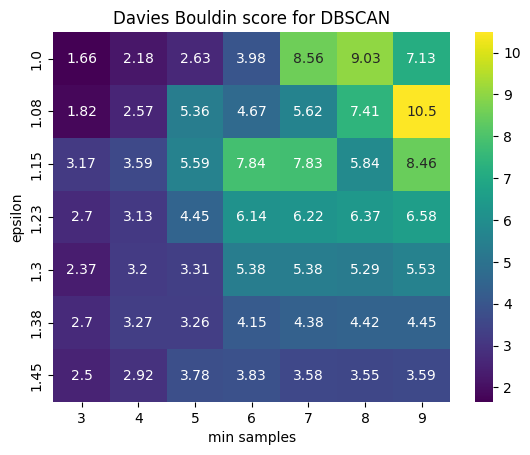

In [177]:
surface = np.ndarray((7, 7))
for i, epsilon in enumerate(np.linspace(1., 1.45, 7)):
    for j, min_samples in enumerate(range(3, 10)):
        surface[i, j] = davies_bouldin_score(
            x, DBSCAN(epsilon, min_samples=min_samples, n_jobs=-1).fit_predict(x)
        )
        print("end ", i, j)
sns.heatmap(surface, cmap="viridis", annot=True, fmt=".3g")
plt.xlabel("min samples")
plt.xticks([el + 0.5 for el in range(7)], list(map(str, range(3, 10))))
plt.yticks([el + 0.5 for el in range(7)], [str(round(num, 2)) for num in np.linspace(1., 1.45, 7)])
plt.ylabel("epsilon")
plt.title("Davies Bouldin score for DBSCAN")
plt.show();

examine sensitivity of DBSCAN to noise and anomalies

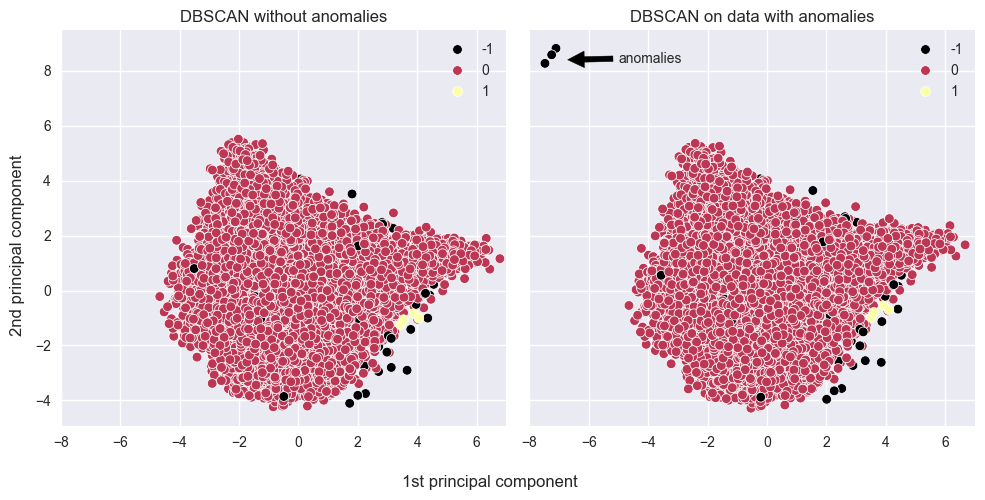

{'anomaly': Counter({np.int64(0): 16111, np.int64(-1): 136, np.int64(1): 6}),
 'without anomaly': Counter({np.int64(0): 16111,
          np.int64(-1): 133,
          np.int64(1): 6})}

In [58]:
## add removed anomalies
x_anom = pd.read_csv("data_files/preprocessed.csv")
x_anom = x_anom.fillna(x_anom.median())
scaler = ColumnTransformer(
    [
        ("std_scaler", StandardScaler(), [
            "popularity", "danceability", "energy", "loudness",
            "valence"
        ]),
        ("log_scaler", FunctionTransformer(
            lambda x: np.log10(x + 1e-14), lambda x: np.power(10, x)
            ), [
                "speechiness", "acousticness", "instrumentalness",
                "duration_ms", "name_len"
        ])
    ],
    remainder="passthrough"
)
x_anom = scaler.fit_transform(x_anom)
x_anom = pd.DataFrame(x_anom, columns=[
    "popularity", "danceability", "energy", "loudness",
    "valence", "speechiness", "acousticness", "instrumentalness",
    "duration_ms", "name_len", "class"
])
x_anom = x_anom.drop(columns="class")
distr_labels = {}
with plt.style.context("seaborn-v0_8"):
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 5))
    data = PCA(2).fit_transform(x_anom)
    labels = DBSCAN(1.4, min_samples=5, n_jobs=-1).fit_predict(x_anom)
    distr_labels["anomaly"] = Counter(labels)
    sns.scatterplot(x=data[:, 0], y=data[:, 1], ax=axs[1], hue=labels, palette="inferno")
    axs[1].set_xlim((-8, 7))
    axs[1].set_title("DBSCAN on data with anomalies")
    axs[1].annotate('anomalies', xy=(-6.8, 8.4), xycoords='data',
            xytext=(-5, 8.7),
            va='top', ha='left',
            arrowprops=dict(facecolor='black', shrink=0.05))
    data = PCA(2).fit_transform(x)
    labels = DBSCAN(1.4, min_samples=5, n_jobs=-1).fit_predict(x)
    distr_labels["without anomaly"] = Counter(labels)
    sns.scatterplot(x=data[:, 0], y=data[:, 1], ax=axs[0], hue=labels, palette="inferno")
    axs[0].set_xlim((-8, 7))
    axs[0].set_title("DBSCAN without anomalies")
    fig.supxlabel("1st principal component")
    fig.supylabel("2nd principal component")
    plt.tight_layout()
    plt.show();
distr_labels

Analysis of clustering

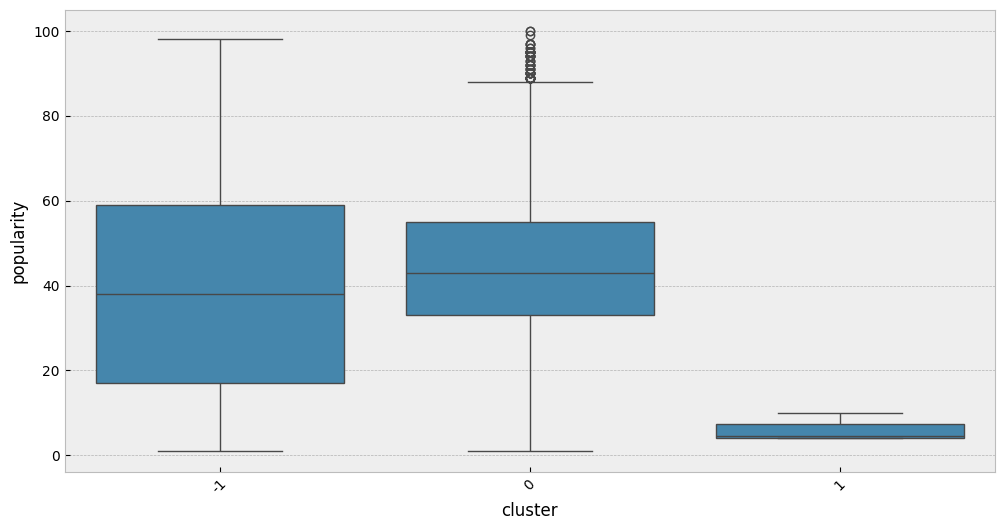

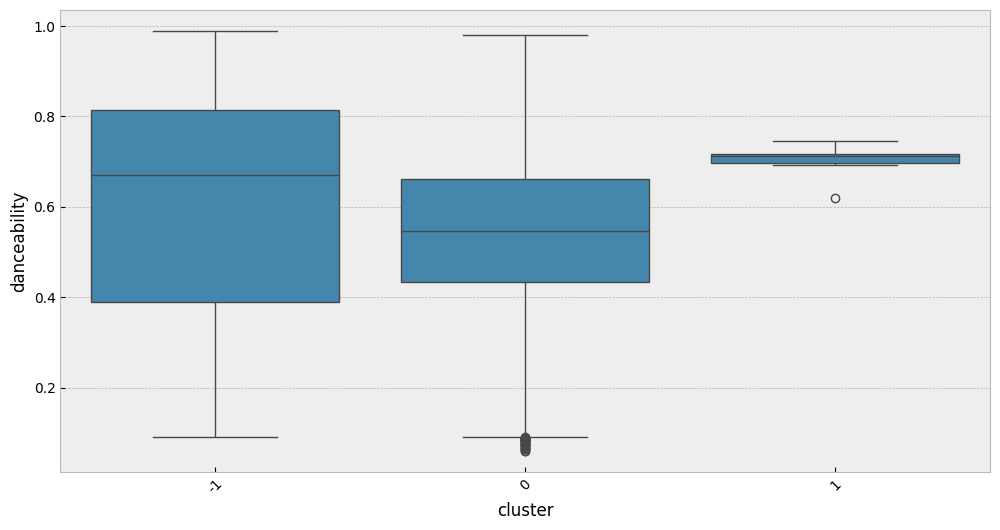

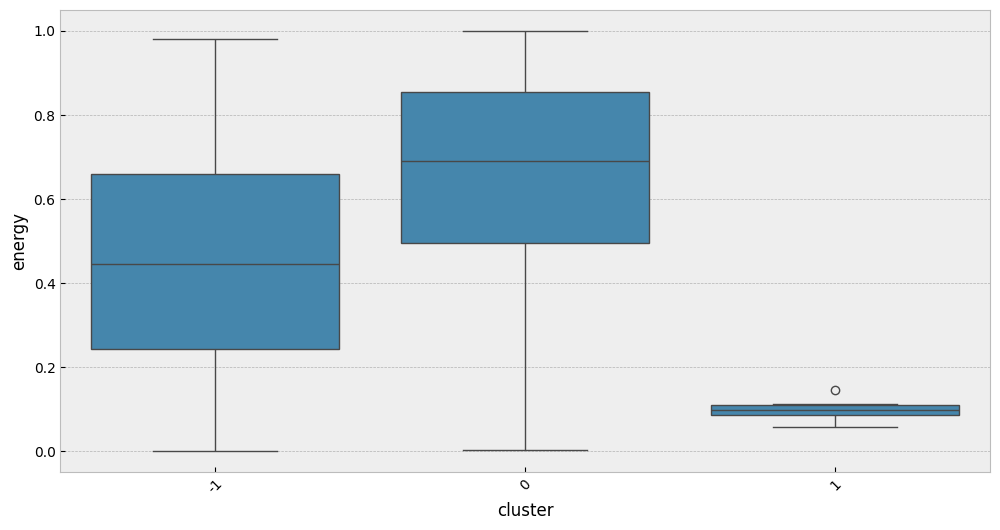

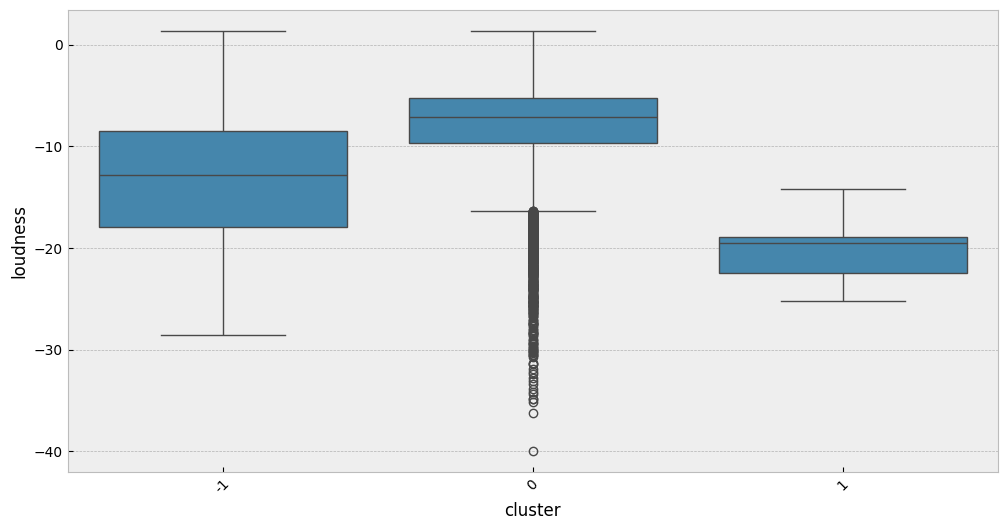

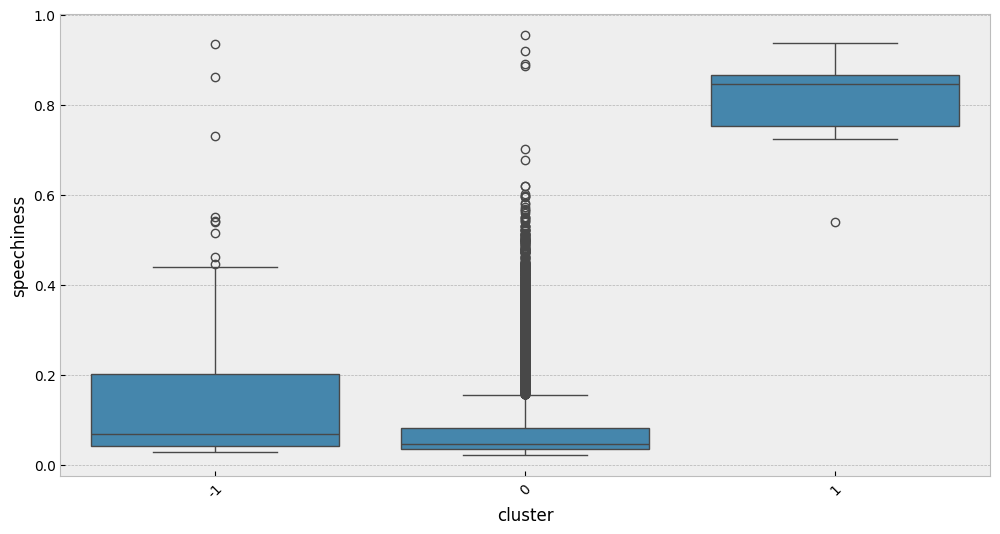

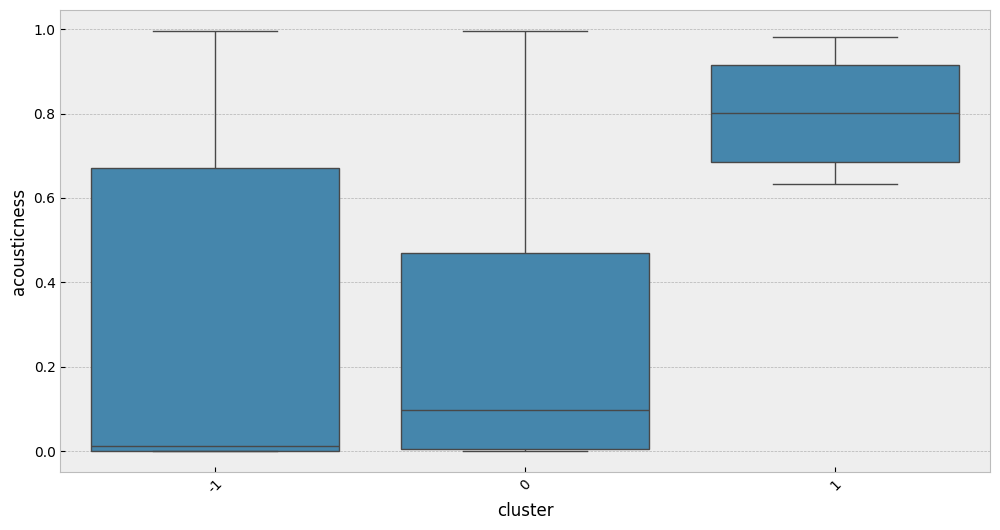

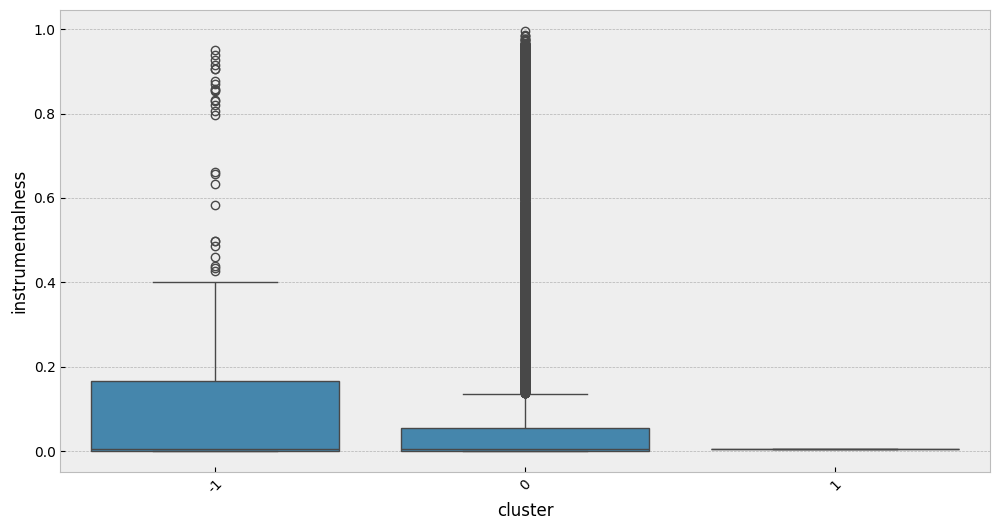

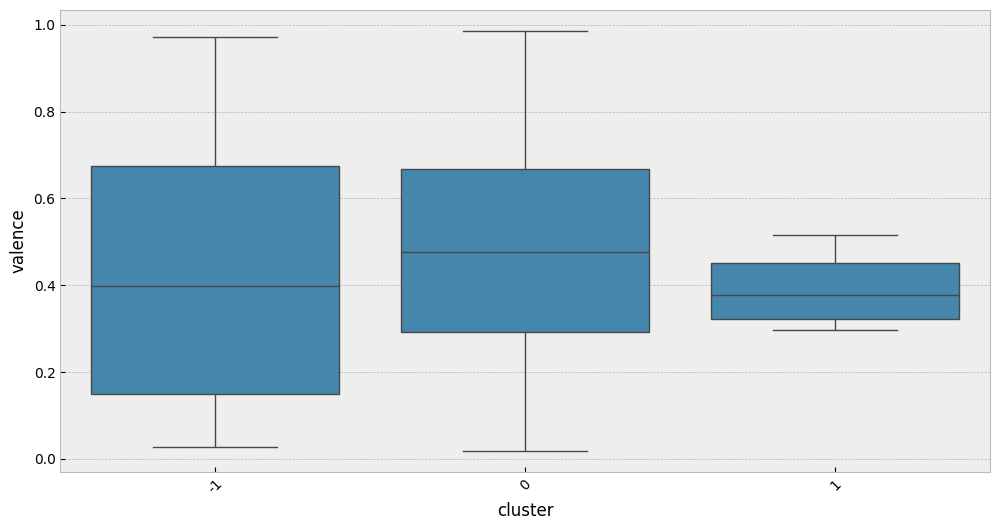

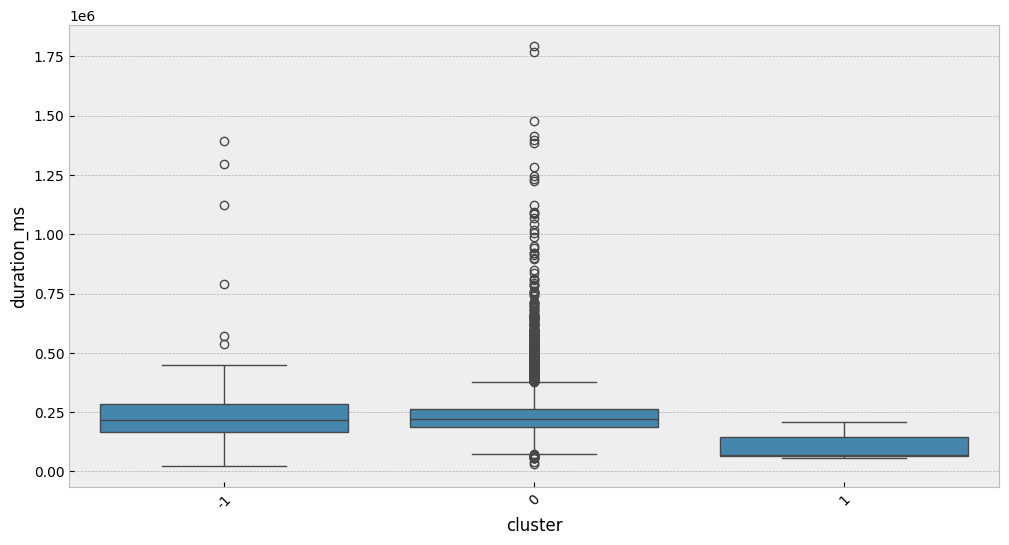

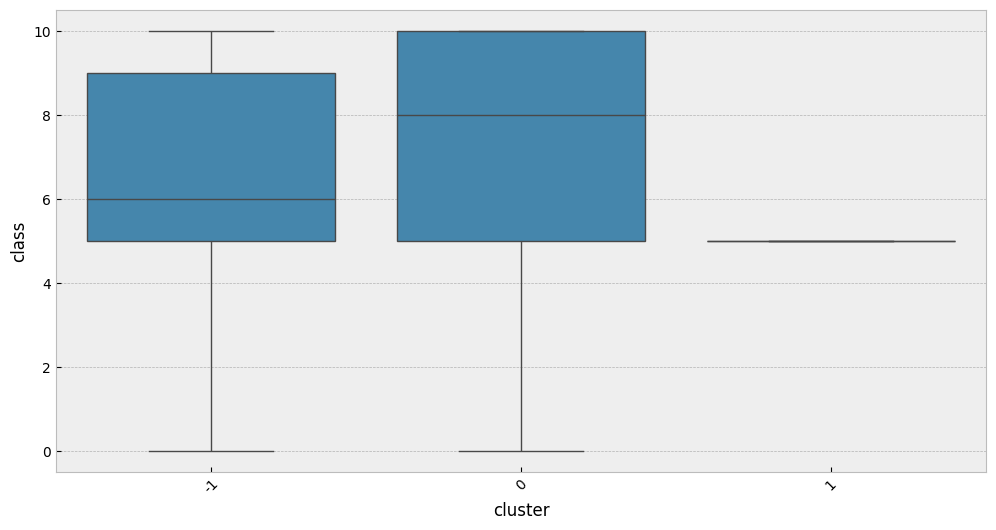

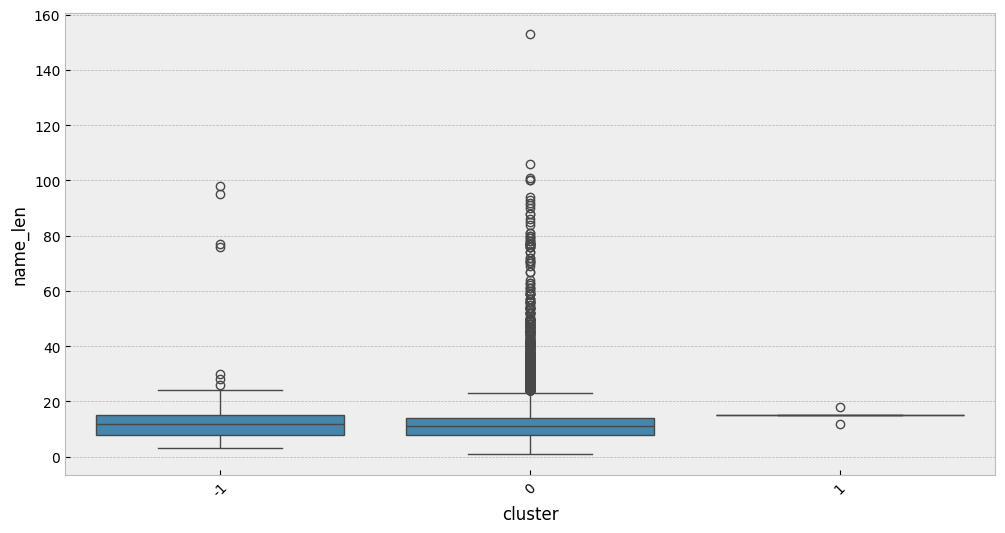

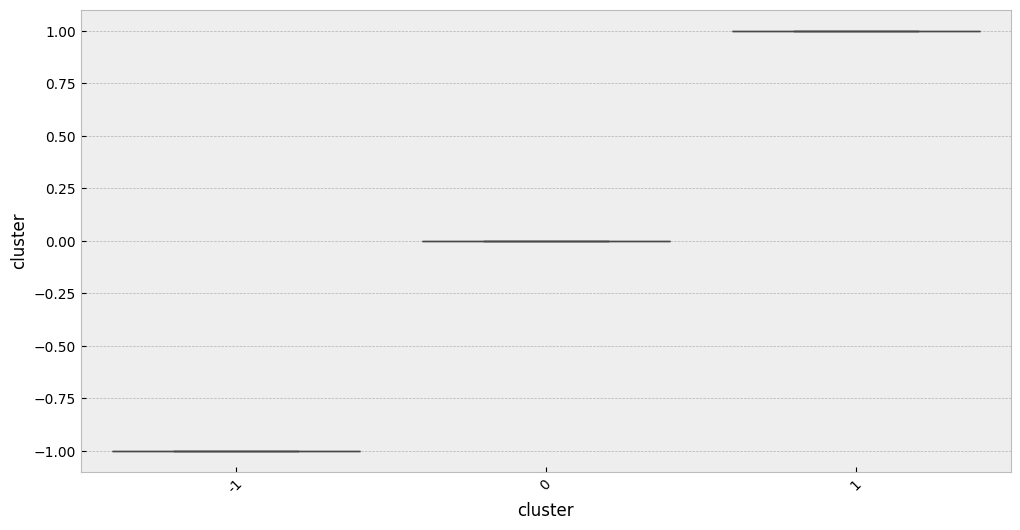

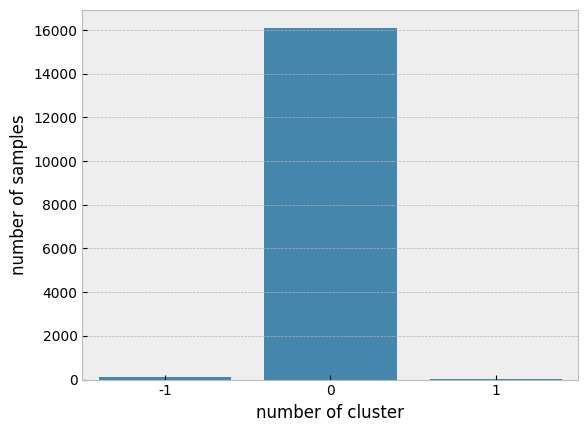

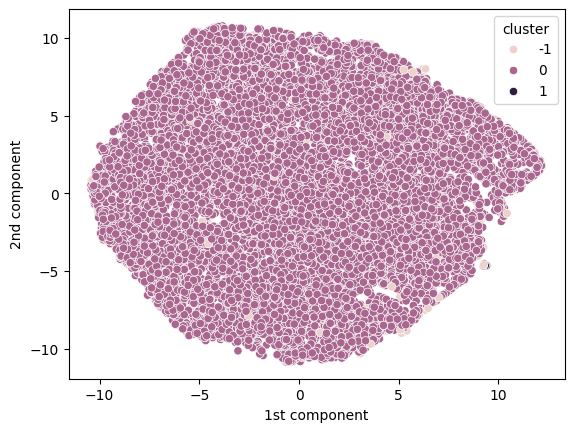

Silhouette score: 0.1478
Calinski Harabasz score: 26.1266
Davies Bouldin score: 3.1398


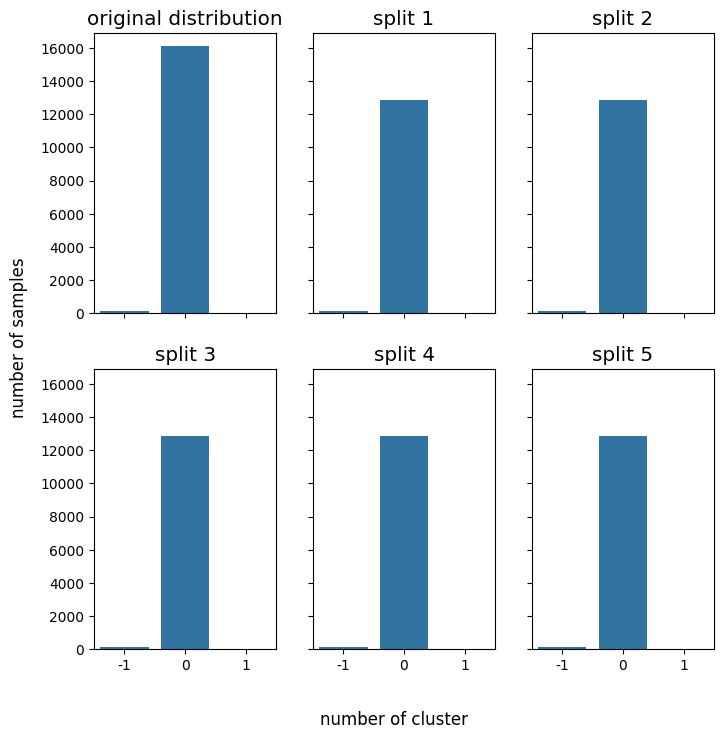

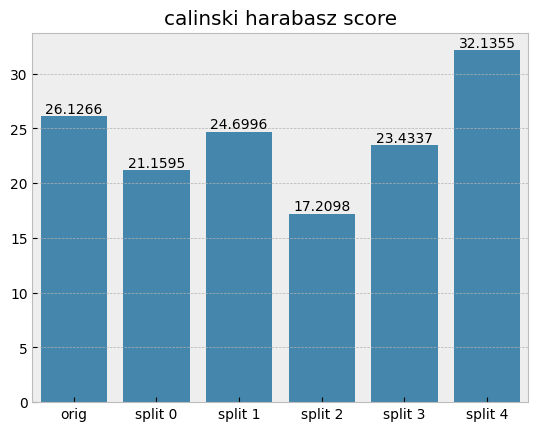

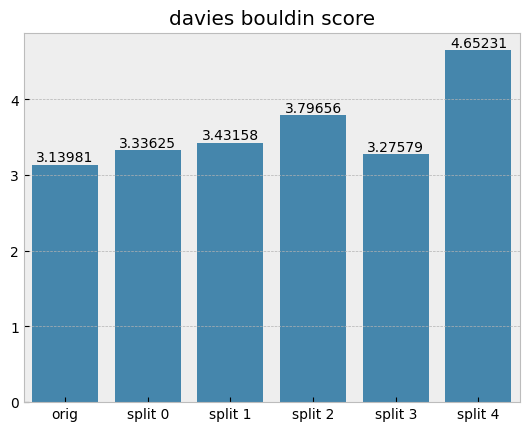

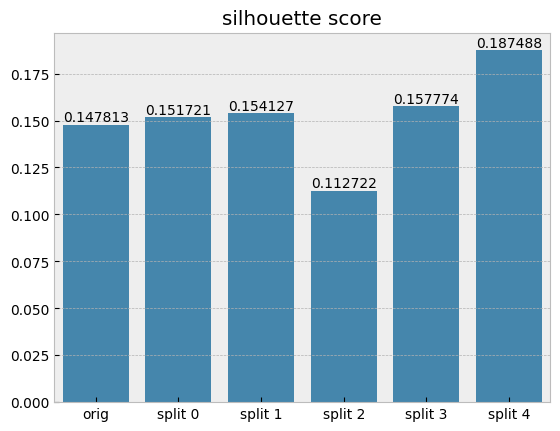

In [22]:
## different clusters haven't mostly differente feature distributions
tmp = df.copy()
tmp["cluster"] = DBSCAN(1.4, min_samples=5, n_jobs=-1).fit_predict(x)
with plt.style.context("bmh"):
    for col in tmp.columns:
        plt.figure(figsize = (12, 6))
        ax = sns.boxplot(x=tmp["cluster"], y=tmp.loc[:, col])
        plt.setp(ax.artists, alpha=.5, linewidth=2, edgecolor="k")
        plt.xticks(rotation=45)
        plt.show();
with plt.style.context("bmh"):
    sns.barplot(data=Counter(tmp["cluster"]))
    plt.xlabel("number of cluster")
    plt.ylabel("number of samples")
    plt.show();
data = TSNE(2, max_iter=300, random_state=17).fit_transform(x)
sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=tmp["cluster"])
plt.xlabel("1st component")
plt.ylabel("2nd component")
plt.show();
print(f"Silhouette score: {round(silhouette_score(x, tmp["cluster"]), 4)}")
print(f"Calinski Harabasz score: {round(calinski_harabasz_score(x, tmp["cluster"]), 4)}")
print(f"Davies Bouldin score: {round(davies_bouldin_score(x, tmp["cluster"]), 4)}")
cl_distr = {}
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(8, 8))
with plt.style.context("bmh"):
    sns.barplot(data=Counter(tmp["cluster"]), ax=axs[0, 0])
    axs[0, 0].set_title("original distribution")
for i, (train, _) in enumerate(StratifiedKFold(5).split(x, y), 1):
    cl = DBSCAN(1.4, min_samples=5, n_jobs=-1).fit_predict(x.iloc[train])
    with plt.style.context("bmh"):
        sns.barplot(data=Counter(cl), ax=axs[i // 3, i % 3])
        axs[i // 3, i % 3].set_title(f"split {i}")
fig.supxlabel("number of cluster")
fig.supylabel("number of samples")
plt.show();
n_splits = 5
clus_distr = {
    "calinski harabasz": [calinski_harabasz_score(x, tmp["cluster"])],
    "davies bouldin": [davies_bouldin_score(x, tmp["cluster"])],
    "silhouette": [silhouette_score(x, tmp["cluster"])]
}
for i, (train, _) in enumerate(StratifiedKFold(n_splits).split(x, y), 1):
    cl = DBSCAN(1.4, min_samples=5, n_jobs=-1).fit_predict(x.iloc[train])
    clus_distr["calinski harabasz"].append(calinski_harabasz_score(x.iloc[train], cl))
    clus_distr["davies bouldin"].append(davies_bouldin_score(x.iloc[train], cl))
    clus_distr["silhouette"].append(silhouette_score(x.iloc[train], cl))

for key in clus_distr:
    with plt.style.context("bmh"):
        ax = sns.barplot(
            x=["orig"] + [f"split {i}" for i in range(n_splits)],
            y=clus_distr[key]
        )
        ax.bar_label(ax.containers[0], fontsize=10)
        plt.title(key + " score")
        plt.show();

In [23]:
for cl in np.unique(tmp["cluster"]):
    print("cluster", cl, "classes", Counter(tmp.loc[tmp.loc[:, "cluster"] == cl, "class"]))

cluster -1 classes Counter({5: 30, 10: 28, 6: 22, 9: 16, 2: 9, 1: 9, 3: 6, 0: 5, 8: 5, 7: 2, 4: 1})
cluster 0 classes Counter({10: 4406, 9: 2372, 6: 2124, 8: 1723, 5: 1368, 2: 1207, 1: 935, 0: 620, 7: 574, 3: 396, 4: 386})
cluster 1 classes Counter({5: 6})


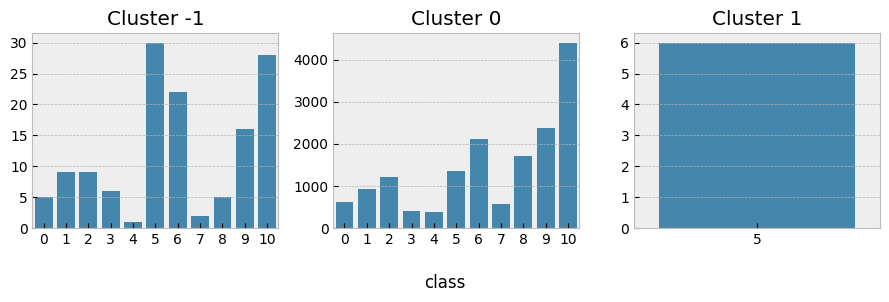

In [51]:
tmp = df.copy()
tmp["cluster"] = DBSCAN(1.4, min_samples=5, n_jobs=-1).fit_predict(x)
with plt.style.context("bmh"):
    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    fig.supxlabel("class")
    for i, cl in enumerate(np.unique(tmp["cluster"])):
        sns.barplot(
            Counter(tmp.loc[tmp.loc[:, "cluster"] == cl, "class"]),
            ax=axs[i]
        )
        axs[i].set_title(f"Cluster {cl}")
plt.tight_layout()
plt.show();